In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb

import kdar_functions as kdar
import general_functions as utils

from matplotlib.pyplot import cm

import importlib



In [19]:
single_run = True

In [20]:
importlib.reload(kdar)
importlib.reload(utils)

<module 'general_functions' from '/Users/bbogart/Documents/analysisCode/kdar_bdt/general_functions.py'>

In [21]:
model_hiE = xgb.Booster({'nthread': 4})  # init model
model_hiE.load_model('model_hiE_777.json')  # load data

model_lowE = xgb.Booster({'nthread': 4})  # init model
model_lowE.load_model('model_lowE_777.json')  # load data

model_hiE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_hiE_genie_only.load_model('model_hiE_genie_only_777.json')  # load data

model_lowE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_lowE_genie_only.load_model('model_lowE_genie_only_777.json')  # load data

lowE_cut = 0.8
hiE_cut = 0.9

bdt_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"
bdt_query_recomb2 = f"kdar_score_hiE_recomb2>{hiE_cut} and kdar_score_lowE_recomb2>{lowE_cut}"
bdt_query_SCE = f"kdar_score_hiE_SCE>{hiE_cut} and kdar_score_lowE_SCE>{lowE_cut}"
bdt_query_lyatt = f"kdar_score_hiE_lyatt>{hiE_cut} and kdar_score_lowE_lyatt>{lowE_cut}"
bdt_query_lyr = f"kdar_score_hiE_lyr>{hiE_cut} and kdar_score_lowE_lyr>{lowE_cut}"
bdt_query_lyd = f"kdar_score_hiE_lyd>{hiE_cut} and kdar_score_lowE_lyd>{lowE_cut}"
bdt_query_WMX = f"kdar_score_hiE_WMX>{hiE_cut} and kdar_score_lowE_WMX>{lowE_cut}"
bdt_query_WMYZ = f"kdar_score_hiE_WMYZ >{hiE_cut} and kdar_score_lowE_WMYZ >{lowE_cut}"
bdt_query_WMthetaXZ = f"kdar_score_hiE_WMthetaXZ>{hiE_cut} and kdar_score_lowE_WMthetaXZ>{lowE_cut}"
bdt_query_WMthetaYZ = f"kdar_score_hiE_WMthetaYZ >{hiE_cut} and kdar_score_lowE_WMthetaYZ >{lowE_cut}"


In [22]:
def check_var(var,xmin,xmax,nbins,
              plot_recomb2=True,plot_SCE=True,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,
              check_bdtsel=False,check_presel=False,check_tagger=False,clipped=False,norm_sig=True,
              logy=False,xlabel_name="",alpha=0.7):

    bins = np.linspace(xmin,xmax,nbins+1)
    err_truth = utils.get_x_err_Enu(utils.get_bin_centers(bins),bins)

    max_y = 0
    clipped_max =  99999999
    clipped_min = -99999999
    if clipped:
        clipped_max = xmax
        clipped_min = xmin       
    
    query = "is_KDAR==1"
    if check_bdtsel: query = "is_KDAR==1 and " + bdt_query
    elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query
    elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy>0"    
    sig_test, _xx = np.histogram(np.clip(kdar_overlay_df.query(query)[var].to_numpy(),clipped_min,clipped_max),
                                    bins=bins,density=False,
                                    weights=kdar_overlay_df.query(query)['net_weight'].to_numpy())
    if norm_sig == True: 
        norm_sig_test = np.sum(sig_test)
        sig_test = sig_test/norm_sig_test
    max_y = np.max(sig_test)
    
    
    
    plt.figure()
    plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')

    if plot_recomb2:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_recomb2
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_recomb2
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_recomb2>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_recomb2"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.8,color='indigo',label='recomb2',lw=2)

    if plot_SCE:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_SCE
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_SCE
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_SCE>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_SCE"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y  
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.8,color='orangered',label='SCE',lw=2)
        
    if plot_lyatt:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_lyatt
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_lyatt
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_lyatt>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_lyatt"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.8,color='green',label='lyatt',lw=2)
        
    if plot_lyd:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_lyd
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_lyd
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_lyd>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_lyd"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.8,color='navy',label='lyd',lw=2)
        
    if plot_lyr:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_lyr
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_lyr
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_lyr>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_lyr"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y  
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.8,color='firebrick',label='lyr',lw=2)

    if plot_WMX:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_WMX
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_WMX
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_WMX>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_WMX"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.9,color='deeppink',label='WMX',lw=2)  


    if plot_WMYZ:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_WMYZ
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_WMYZ
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_WMYZ>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_WMYZ"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.9,color='lime',label='WMYZ',lw=2)  

    
    if plot_WMthetaXZ:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_WMthetaXZ
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_WMthetaXZ
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_WMthetaXZ>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_WMthetaXZ"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=0.9,color='goldenrod',label='WMthetaXZ',lw=2)  
        
    if plot_WMthetaYZ:
        query = "is_KDAR==1"
        if check_bdtsel: query = "is_KDAR==1 and " + bdt_query_WMthetaYZ
        elif check_presel: query = "is_KDAR==1 and " + kdar.presel_query_WMthetaYZ
        elif check_tagger: query = "is_KDAR==1 and ssm_kine_energy_WMthetaYZ>0"   
        y,x=np.histogram(np.clip(kdar_overlay_df.query(query)[var+"_WMthetaYZ"].to_numpy(),clipped_min,clipped_max),
                 bins=nbins, range=(xmin,xmax),
                 weights=kdar_overlay_df.query(query)["net_weight"].to_numpy(),         
        )      
        if norm_sig: 
            norm_y = np.sum(y)
            y = y/norm_y   
        max_y = np.max([max_y,np.max(y)])
        plt.stairs(y,edges=bins,alpha=1,color='dodgerblue',label='WMthetaYZ',lw=2)  
        
    plt.xlabel(var)
    if xlabel_name!="": plt.xlabel(xlabel_name)
    if norm_sig: plt.ylabel("Normalized Counts")
    else: plt.ylabel("Events")
    plt.legend(title='Signal')
    if check_bdtsel: plt.legend(title='BDT Selected Signal')
    elif check_presel: plt.legend(title='Preselected Signal')
    elif check_tagger: plt.legend(title='Tagged Signal')
    plt.ylim(0,1.05*max_y)
    if logy: plt.yscale("log")
    plt.show()



In [23]:


f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_lyatt_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_cv"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_cv"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_cv"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_cv"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

kdar_overlay_df["net_weight"] = kdar_overlay_df["weight_cv"].to_numpy()*kdar_overlay_df["weight_spline"].to_numpy()
print("All events",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))
kdar_overlay_df["rse_num"] = (kdar_overlay_df["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df["event"].to_numpy())
kdar_overlay_df = kdar_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df = kdar.apply_goodruns(kdar_overlay_df)

kdar_overlay_df["horncur"] = ["RHC" for i in range(kdar_overlay_df.shape[0])]

kdar_overlay_df = kdar_overlay_df.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["isEXT"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["isDirt"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["POTscaled"] = [1 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["is_KDAR"] = [1 for i in range(kdar_overlay_df.shape[0])]








f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_lyatt = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("lyatt: All Events",kdar_overlay_df_lyatt.shape[0])
kdar_overlay_df_lyatt["rse_num"] = (kdar_overlay_df_lyatt["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_lyatt["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_lyatt["event"].to_numpy())
kdar_overlay_df_lyatt = kdar_overlay_df_lyatt.drop_duplicates(subset=['rse_num'])
print("lyatt: Duplicates Dropped",kdar_overlay_df_lyatt.shape[0])


kdar_overlay_df_lyatt = kdar.apply_goodruns(kdar_overlay_df_lyatt)

kdar_overlay_df_lyatt["horncur"] = ["RHC" for i in range(kdar_overlay_df_lyatt.shape[0])]

kdar_overlay_df_lyatt = kdar_overlay_df_lyatt.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_lyatt.shape[0])

kdar_overlay_df_lyatt["isEXT"] = [0 for i in range(kdar_overlay_df_lyatt.shape[0])]
kdar_overlay_df_lyatt["isDirt"] = [0 for i in range(kdar_overlay_df_lyatt.shape[0])]
kdar_overlay_df_lyatt["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_lyatt.shape[0])]
kdar_overlay_df_lyatt["POTscaled"] = [1 for i in range(kdar_overlay_df_lyatt.shape[0])]
kdar_overlay_df_lyatt["is_KDAR"] = [1 for i in range(kdar_overlay_df_lyatt.shape[0])]






f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_lyr_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_lyr = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("lyr: All Events",kdar_overlay_df_lyr.shape[0])
kdar_overlay_df_lyr["rse_num"] = (kdar_overlay_df_lyr["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_lyr["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_lyr["event"].to_numpy())
kdar_overlay_df_lyr = kdar_overlay_df_lyr.drop_duplicates(subset=['rse_num'])
print("lyr: Duplicates Dropped",kdar_overlay_df_lyr.shape[0])


kdar_overlay_df_lyr = kdar.apply_goodruns(kdar_overlay_df_lyr)

kdar_overlay_df_lyr["horncur"] = ["RHC" for i in range(kdar_overlay_df_lyr.shape[0])]

kdar_overlay_df_lyr = kdar_overlay_df_lyr.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_lyr.shape[0])

kdar_overlay_df_lyr["isEXT"] = [0 for i in range(kdar_overlay_df_lyr.shape[0])]
kdar_overlay_df_lyr["isDirt"] = [0 for i in range(kdar_overlay_df_lyr.shape[0])]
kdar_overlay_df_lyr["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_lyr.shape[0])]
kdar_overlay_df_lyr["POTscaled"] = [1 for i in range(kdar_overlay_df_lyr.shape[0])]
kdar_overlay_df_lyr["is_KDAR"] = [1 for i in range(kdar_overlay_df_lyr.shape[0])]








f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_lyd_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_lyd = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("lyd: All Events",kdar_overlay_df_lyd.shape[0])
kdar_overlay_df_lyd["rse_num"] = (kdar_overlay_df_lyd["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_lyd["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_lyd["event"].to_numpy())
kdar_overlay_df_lyd = kdar_overlay_df_lyd.drop_duplicates(subset=['rse_num'])
print("lyd: Duplicates Dropped",kdar_overlay_df_lyd.shape[0])


kdar_overlay_df_lyd = kdar.apply_goodruns(kdar_overlay_df_lyd)

kdar_overlay_df_lyd["horncur"] = ["RHC" for i in range(kdar_overlay_df_lyd.shape[0])]

kdar_overlay_df_lyd = kdar_overlay_df_lyd.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_lyd.shape[0])

kdar_overlay_df_lyd["isEXT"] = [0 for i in range(kdar_overlay_df_lyd.shape[0])]
kdar_overlay_df_lyd["isDirt"] = [0 for i in range(kdar_overlay_df_lyd.shape[0])]
kdar_overlay_df_lyd["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_lyd.shape[0])]
kdar_overlay_df_lyd["POTscaled"] = [1 for i in range(kdar_overlay_df_lyd.shape[0])]
kdar_overlay_df_lyd["is_KDAR"] = [1 for i in range(kdar_overlay_df_lyd.shape[0])]






f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_WMX_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_WMX = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("WMX: All Events",kdar_overlay_df_WMX.shape[0])
kdar_overlay_df_WMX["rse_num"] = (kdar_overlay_df_WMX["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_WMX["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_WMX["event"].to_numpy())
kdar_overlay_df_WMX = kdar_overlay_df_WMX.drop_duplicates(subset=['rse_num'])
print("WMX: Duplicates Dropped",kdar_overlay_df_WMX.shape[0])


kdar_overlay_df_WMX = kdar.apply_goodruns(kdar_overlay_df_WMX)

kdar_overlay_df_WMX["horncur"] = ["RHC" for i in range(kdar_overlay_df_WMX.shape[0])]

kdar_overlay_df_WMX = kdar_overlay_df_WMX.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_WMX.shape[0])

kdar_overlay_df_WMX["isEXT"] = [0 for i in range(kdar_overlay_df_WMX.shape[0])]
kdar_overlay_df_WMX["isDirt"] = [0 for i in range(kdar_overlay_df_WMX.shape[0])]
kdar_overlay_df_WMX["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_WMX.shape[0])]
kdar_overlay_df_WMX["POTscaled"] = [1 for i in range(kdar_overlay_df_WMX.shape[0])]
kdar_overlay_df_WMX["is_KDAR"] = [1 for i in range(kdar_overlay_df_WMX.shape[0])]





f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_WMYZ_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_WMYZ = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("WMYZ: All Events",kdar_overlay_df_WMYZ.shape[0])
kdar_overlay_df_WMYZ["rse_num"] = (kdar_overlay_df_WMYZ["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_WMYZ["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_WMYZ["event"].to_numpy())
kdar_overlay_df_WMYZ = kdar_overlay_df_WMYZ.drop_duplicates(subset=['rse_num'])
print("WMYZ: Duplicates Dropped",kdar_overlay_df_WMYZ.shape[0])


kdar_overlay_df_WMYZ = kdar.apply_goodruns(kdar_overlay_df_WMYZ)

kdar_overlay_df_WMYZ["horncur"] = ["RHC" for i in range(kdar_overlay_df_WMYZ.shape[0])]

kdar_overlay_df_WMYZ = kdar_overlay_df_WMYZ.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_WMYZ.shape[0])

kdar_overlay_df_WMYZ["isEXT"] = [0 for i in range(kdar_overlay_df_WMYZ.shape[0])]
kdar_overlay_df_WMYZ["isDirt"] = [0 for i in range(kdar_overlay_df_WMYZ.shape[0])]
kdar_overlay_df_WMYZ["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_WMYZ.shape[0])]
kdar_overlay_df_WMYZ["POTscaled"] = [1 for i in range(kdar_overlay_df_WMYZ.shape[0])]
kdar_overlay_df_WMYZ["is_KDAR"] = [1 for i in range(kdar_overlay_df_WMYZ.shape[0])]







f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_WMthetaXZ_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_WMthetaXZ = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("WMthetaXZ: All Events",kdar_overlay_df_WMthetaXZ.shape[0])
kdar_overlay_df_WMthetaXZ["rse_num"] = (kdar_overlay_df_WMthetaXZ["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_WMthetaXZ["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_WMthetaXZ["event"].to_numpy())
kdar_overlay_df_WMthetaXZ = kdar_overlay_df_WMthetaXZ.drop_duplicates(subset=['rse_num'])
print("WMthetaXZ: Duplicates Dropped",kdar_overlay_df_WMthetaXZ.shape[0])


kdar_overlay_df_WMthetaXZ = kdar.apply_goodruns(kdar_overlay_df_WMthetaXZ)

kdar_overlay_df_WMthetaXZ["horncur"] = ["RHC" for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]

kdar_overlay_df_WMthetaXZ = kdar_overlay_df_WMthetaXZ.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_WMthetaXZ.shape[0])

kdar_overlay_df_WMthetaXZ["isEXT"] = [0 for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]
kdar_overlay_df_WMthetaXZ["isDirt"] = [0 for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]
kdar_overlay_df_WMthetaXZ["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]
kdar_overlay_df_WMthetaXZ["POTscaled"] = [1 for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]
kdar_overlay_df_WMthetaXZ["is_KDAR"] = [1 for i in range(kdar_overlay_df_WMthetaXZ.shape[0])]






f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_WMthetaYZ_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_WMthetaYZ = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("WMthetaYZ: All Events",kdar_overlay_df_WMthetaYZ.shape[0])
kdar_overlay_df_WMthetaYZ["rse_num"] = (kdar_overlay_df_WMthetaYZ["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_WMthetaYZ["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_WMthetaYZ["event"].to_numpy())
kdar_overlay_df_WMthetaYZ = kdar_overlay_df_WMthetaYZ.drop_duplicates(subset=['rse_num'])
print("WMthetaYZ: Duplicates Dropped",kdar_overlay_df_WMthetaYZ.shape[0])


kdar_overlay_df_WMthetaYZ = kdar.apply_goodruns(kdar_overlay_df_WMthetaYZ)

kdar_overlay_df_WMthetaYZ["horncur"] = ["RHC" for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]

kdar_overlay_df_WMthetaYZ = kdar_overlay_df_WMthetaYZ.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_WMthetaYZ.shape[0])

kdar_overlay_df_WMthetaYZ["isEXT"] = [0 for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]
kdar_overlay_df_WMthetaYZ["isDirt"] = [0 for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]
kdar_overlay_df_WMthetaYZ["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]
kdar_overlay_df_WMthetaYZ["POTscaled"] = [1 for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]
kdar_overlay_df_WMthetaYZ["is_KDAR"] = [1 for i in range(kdar_overlay_df_WMthetaYZ.shape[0])]




f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_SCE_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_SCE = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("SCE: All Events",kdar_overlay_df_SCE.shape[0])
kdar_overlay_df_SCE["rse_num"] = (kdar_overlay_df_SCE["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_SCE["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_SCE["event"].to_numpy())
kdar_overlay_df_SCE = kdar_overlay_df_SCE.drop_duplicates(subset=['rse_num'])
print("SCE: Duplicates Dropped",kdar_overlay_df_SCE.shape[0])


kdar_overlay_df_SCE = kdar.apply_goodruns(kdar_overlay_df_SCE)

kdar_overlay_df_SCE["horncur"] = ["RHC" for i in range(kdar_overlay_df_SCE.shape[0])]

kdar_overlay_df_SCE = kdar_overlay_df_SCE.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_SCE.shape[0])

kdar_overlay_df_SCE["isEXT"] = [0 for i in range(kdar_overlay_df_SCE.shape[0])]
kdar_overlay_df_SCE["isDirt"] = [0 for i in range(kdar_overlay_df_SCE.shape[0])]
kdar_overlay_df_SCE["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_SCE.shape[0])]
kdar_overlay_df_SCE["POTscaled"] = [1 for i in range(kdar_overlay_df_SCE.shape[0])]
kdar_overlay_df_SCE["is_KDAR"] = [1 for i in range(kdar_overlay_df_SCE.shape[0])]





f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_detvar_recomb2_run5.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars_det"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval_det"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars, flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval_det"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars_det"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
kdar_overlay_df_recomb2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

print("recomb2: All Events",kdar_overlay_df_recomb2.shape[0])
kdar_overlay_df_recomb2["rse_num"] = (kdar_overlay_df_recomb2["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df_recomb2["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df_recomb2["event"].to_numpy())
kdar_overlay_df_recomb2 = kdar_overlay_df_recomb2.drop_duplicates(subset=['rse_num'])
print("recomb2: Duplicates Dropped",kdar_overlay_df_recomb2.shape[0])


kdar_overlay_df_recomb2 = kdar.apply_goodruns(kdar_overlay_df_recomb2)

kdar_overlay_df_recomb2["horncur"] = ["RHC" for i in range(kdar_overlay_df_recomb2.shape[0])]

kdar_overlay_df_recomb2 = kdar_overlay_df_recomb2.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df_recomb2.shape[0])

kdar_overlay_df_recomb2["isEXT"] = [0 for i in range(kdar_overlay_df_recomb2.shape[0])]
kdar_overlay_df_recomb2["isDirt"] = [0 for i in range(kdar_overlay_df_recomb2.shape[0])]
kdar_overlay_df_recomb2["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df_recomb2.shape[0])]
kdar_overlay_df_recomb2["POTscaled"] = [1 for i in range(kdar_overlay_df_recomb2.shape[0])]
kdar_overlay_df_recomb2["is_KDAR"] = [1 for i in range(kdar_overlay_df_recomb2.shape[0])]

All events 59891 60795.055
Duplicates Dropped 59891 60795.055
In FV 53204 53886.4
lyatt: All Events 59891
lyatt: Duplicates Dropped 59891
In FV 53204
lyr: All Events 59714
lyr: Duplicates Dropped 59714
In FV 53041
lyd: All Events 59441
lyd: Duplicates Dropped 59441
In FV 52821
WMX: All Events 48786
WMX: Duplicates Dropped 48786
In FV 43000
WMYZ: All Events 56937
WMYZ: Duplicates Dropped 56937
In FV 50477
WMthetaXZ: All Events 55279
WMthetaXZ: Duplicates Dropped 55279
In FV 49192
WMthetaYZ: All Events 59809
WMthetaYZ: Duplicates Dropped 59809
In FV 53140
SCE: All Events 58337
SCE: Duplicates Dropped 58337
In FV 51811
recomb2: All Events 55736
recomb2: Duplicates Dropped 55736
In FV 49361


In [24]:

kdar_overlay_df = kdar.add_ntrue_nu_angle(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_muon_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_ssm_info(kdar_overlay_df)


100%|██████████████████████████████████| 53204/53204 [00:00<00:00, 56185.26it/s]


In [25]:
kdar_overlay_df = kdar.add_ssm_kine_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_reco_proton_muon(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df)

kdar_overlay_df_SCE = kdar.add_ssm_kine_info(kdar_overlay_df_SCE)
kdar_overlay_df_SCE = kdar.add_ssm_reco_proton_info(kdar_overlay_df_SCE)
kdar_overlay_df_SCE = kdar.add_reco_proton_muon(kdar_overlay_df_SCE)
kdar_overlay_df_SCE = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_SCE)

kdar_overlay_df_recomb2 = kdar.add_ssm_kine_info(kdar_overlay_df_recomb2)
kdar_overlay_df_recomb2 = kdar.add_ssm_reco_proton_info(kdar_overlay_df_recomb2)
kdar_overlay_df_recomb2 = kdar.add_reco_proton_muon(kdar_overlay_df_recomb2)
kdar_overlay_df_recomb2 = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_recomb2)

kdar_overlay_df_lyatt = kdar.add_ssm_kine_info(kdar_overlay_df_lyatt)
kdar_overlay_df_lyatt = kdar.add_ssm_reco_proton_info(kdar_overlay_df_lyatt)
kdar_overlay_df_lyatt = kdar.add_reco_proton_muon(kdar_overlay_df_lyatt)
kdar_overlay_df_lyatt = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_lyatt)

kdar_overlay_df_lyr = kdar.add_ssm_kine_info(kdar_overlay_df_lyr)
kdar_overlay_df_lyr = kdar.add_ssm_reco_proton_info(kdar_overlay_df_lyr)
kdar_overlay_df_lyr = kdar.add_reco_proton_muon(kdar_overlay_df_lyr)
kdar_overlay_df_lyr = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_lyr)

kdar_overlay_df_lyd = kdar.add_ssm_kine_info(kdar_overlay_df_lyd)
kdar_overlay_df_lyd = kdar.add_ssm_reco_proton_info(kdar_overlay_df_lyd)
kdar_overlay_df_lyd = kdar.add_reco_proton_muon(kdar_overlay_df_lyd)
kdar_overlay_df_lyd = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_lyd)

kdar_overlay_df_WMX = kdar.add_ssm_kine_info(kdar_overlay_df_WMX)
kdar_overlay_df_WMX = kdar.add_ssm_reco_proton_info(kdar_overlay_df_WMX)
kdar_overlay_df_WMX = kdar.add_reco_proton_muon(kdar_overlay_df_WMX)
kdar_overlay_df_WMX = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_WMX)

kdar_overlay_df_WMYZ = kdar.add_ssm_kine_info(kdar_overlay_df_WMYZ)
kdar_overlay_df_WMYZ = kdar.add_ssm_reco_proton_info(kdar_overlay_df_WMYZ)
kdar_overlay_df_WMYZ = kdar.add_reco_proton_muon(kdar_overlay_df_WMYZ)
kdar_overlay_df_WMYZ = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_WMYZ)

kdar_overlay_df_WMthetaXZ = kdar.add_ssm_kine_info(kdar_overlay_df_WMthetaXZ)
kdar_overlay_df_WMthetaXZ = kdar.add_ssm_reco_proton_info(kdar_overlay_df_WMthetaXZ)
kdar_overlay_df_WMthetaXZ = kdar.add_reco_proton_muon(kdar_overlay_df_WMthetaXZ)
kdar_overlay_df_WMthetaXZ = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_WMthetaXZ)

kdar_overlay_df_WMthetaYZ = kdar.add_ssm_kine_info(kdar_overlay_df_WMthetaYZ)
kdar_overlay_df_WMthetaYZ = kdar.add_ssm_reco_proton_info(kdar_overlay_df_WMthetaYZ)
kdar_overlay_df_WMthetaYZ = kdar.add_reco_proton_muon(kdar_overlay_df_WMthetaYZ)
kdar_overlay_df_WMthetaYZ = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df_WMthetaYZ)


100%|█████████████████████████████████| 53204/53204 [00:00<00:00, 599874.06it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2445: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_angle_P_deg"] = np.array(angle_P)*180/3.14
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2446: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_cosMuP"] = cosMuP
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2447: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

In [26]:
kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_SCE = kdar.add_bdt_scores(kdar_overlay_df_SCE,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_SCE = kdar.add_bdt_scores(kdar_overlay_df_SCE,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_recomb2 = kdar.add_bdt_scores(kdar_overlay_df_recomb2,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_recomb2 = kdar.add_bdt_scores(kdar_overlay_df_recomb2,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_lyatt = kdar.add_bdt_scores(kdar_overlay_df_lyatt,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_lyatt = kdar.add_bdt_scores(kdar_overlay_df_lyatt,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_lyr = kdar.add_bdt_scores(kdar_overlay_df_lyr,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_lyr = kdar.add_bdt_scores(kdar_overlay_df_lyr,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_lyd = kdar.add_bdt_scores(kdar_overlay_df_lyd,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_lyd = kdar.add_bdt_scores(kdar_overlay_df_lyd,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_WMX = kdar.add_bdt_scores(kdar_overlay_df_WMX,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_WMX = kdar.add_bdt_scores(kdar_overlay_df_WMX,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_WMYZ = kdar.add_bdt_scores(kdar_overlay_df_WMYZ,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_WMYZ = kdar.add_bdt_scores(kdar_overlay_df_WMYZ,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_WMthetaXZ = kdar.add_bdt_scores(kdar_overlay_df_WMthetaXZ,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_WMthetaXZ = kdar.add_bdt_scores(kdar_overlay_df_WMthetaXZ,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

kdar_overlay_df_WMthetaYZ = kdar.add_bdt_scores(kdar_overlay_df_WMthetaYZ,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df_WMthetaYZ = kdar.add_bdt_scores(kdar_overlay_df_WMthetaYZ,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1753: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bdtvarname] = d_pred
100%|█████████████████████████████████| 53204/53204 [00:00<00:00, 964013.71it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1753: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bdtvarname] = d_pred
100%|█████████████████████████████████| 53140/53140 [00:00<00:00, 952928.94it/s]


In [27]:

print("CV",kdar_overlay_df.shape[0])
print("SCE",kdar_overlay_df_SCE.shape[0])
print("recomb2",kdar_overlay_df_recomb2.shape[0])
print("lyatt",kdar_overlay_df_lyatt.shape[0])
print("lyr",kdar_overlay_df_lyr.shape[0])
print("lyd",kdar_overlay_df_lyd.shape[0])
print("WMZ",kdar_overlay_df_WMX.shape[0])
print("WMthetaXZ",kdar_overlay_df_WMthetaXZ.shape[0])
print("WMthetaYZ",kdar_overlay_df_WMthetaYZ.shape[0])
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_SCE,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_SCE'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_recomb2,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_recomb2'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_lyatt,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_lyatt'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_lyr,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_lyr'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_lyd,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_lyd'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_WMX,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_WMX'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_WMYZ,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_WMYZ'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_WMthetaXZ,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_WMthetaXZ'))
kdar_overlay_df = kdar_overlay_df.merge(kdar_overlay_df_WMthetaYZ,how='inner',left_on='rse_num',right_on='rse_num',suffixes=('', '_WMthetaYZ'))
print("Merged",kdar_overlay_df.shape[0])

del kdar_overlay_df_SCE
del kdar_overlay_df_recomb2
del kdar_overlay_df_lyatt
del kdar_overlay_df_lyr
del kdar_overlay_df_lyd
del kdar_overlay_df_WMX
del kdar_overlay_df_WMthetaXZ
del kdar_overlay_df_WMthetaYZ


CV 53204
SCE 51811
recomb2 49361
lyatt 53204
lyr 53041
lyd 52821
WMZ 43000
WMthetaXZ 49192
WMthetaYZ 53140
Merged 32897


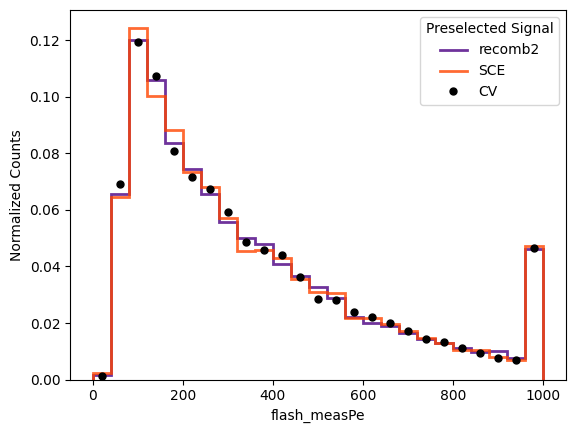

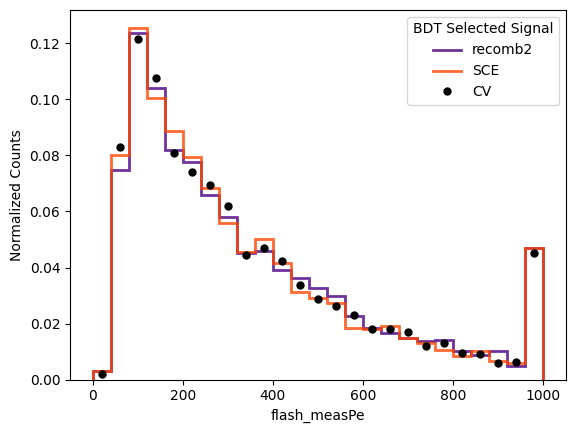

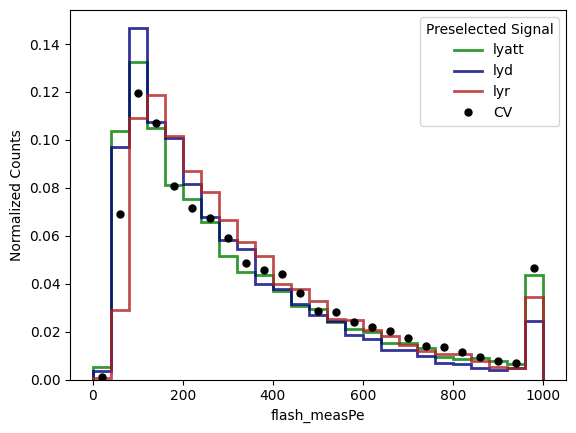

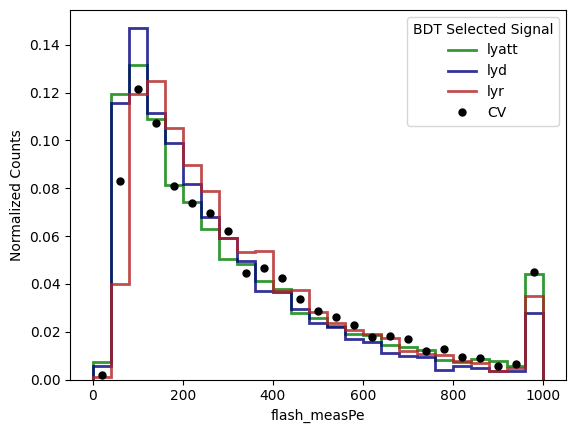

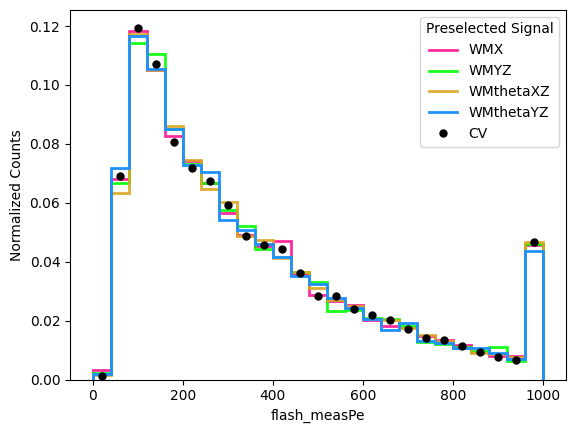

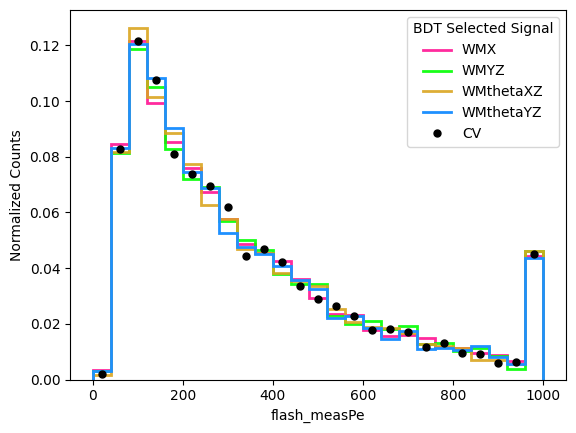

In [28]:

var = 'flash_measPe'
xmin = 0
xmax = 1000
nbins = 25
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


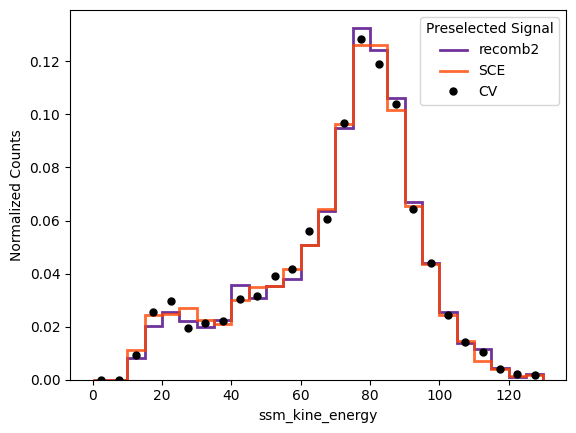

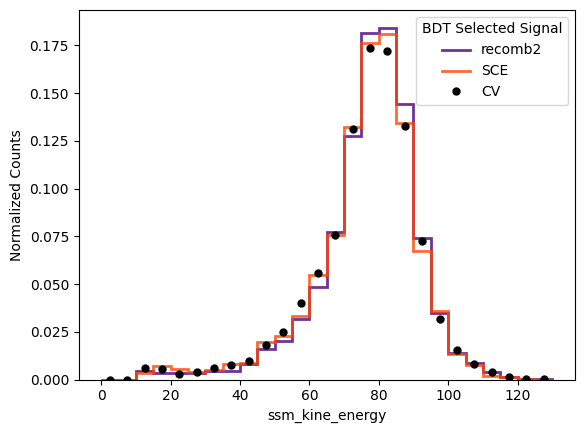

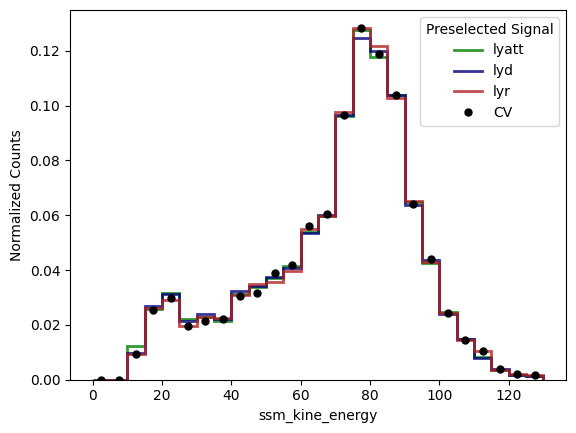

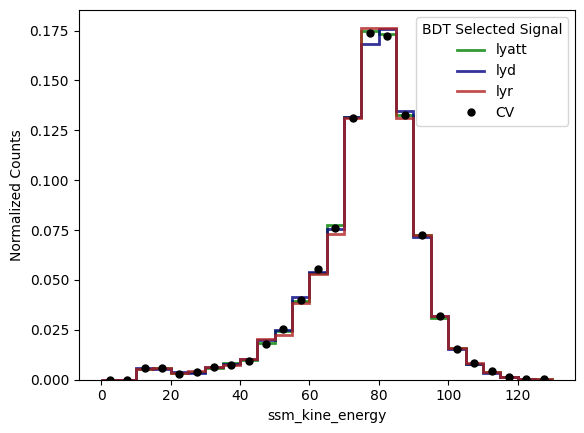

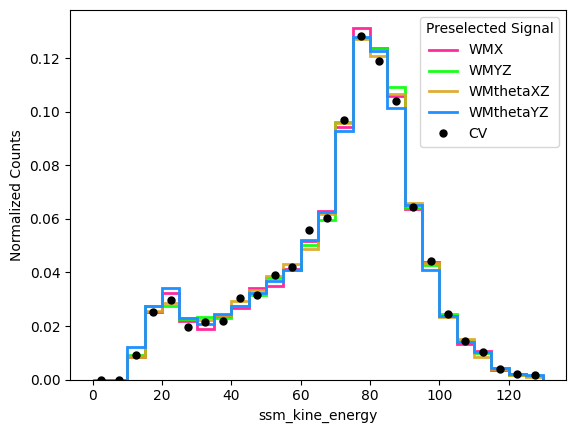

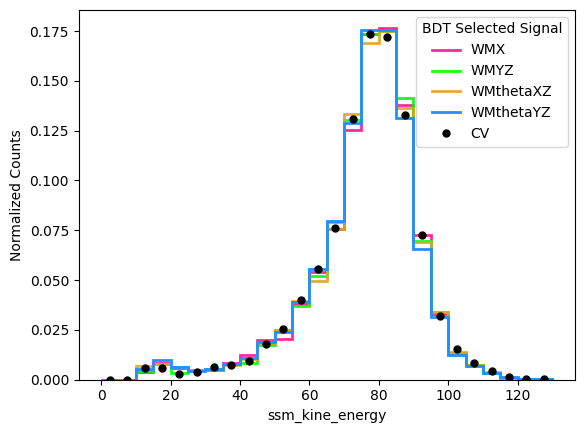

In [29]:
var = 'ssm_kine_energy'
xmin = 0
xmax = 130
nbins = 26
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



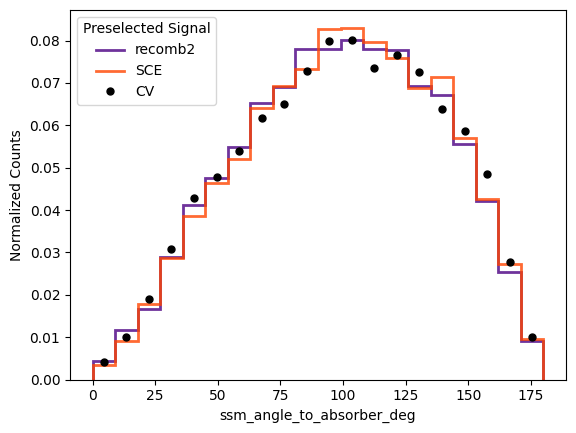

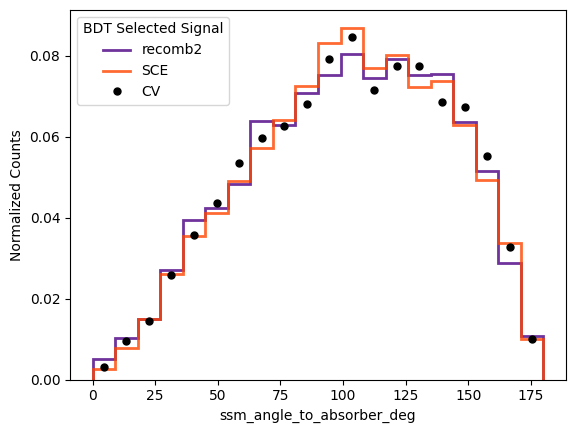

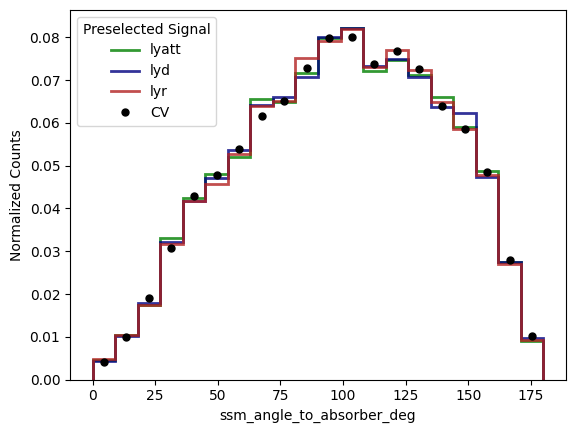

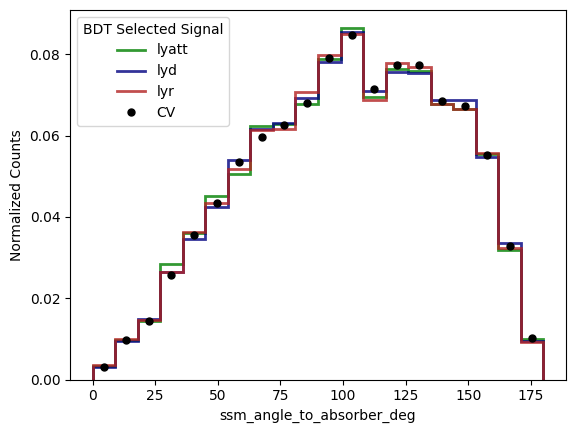

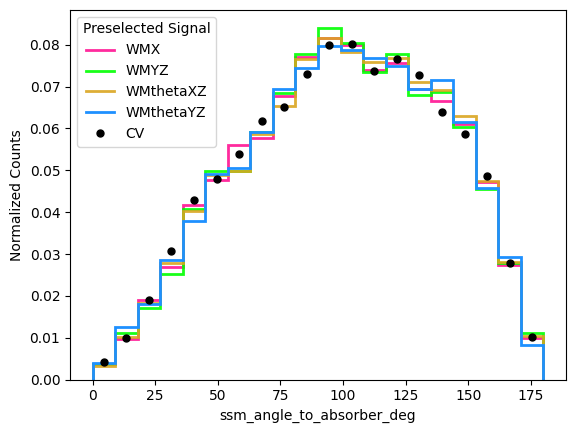

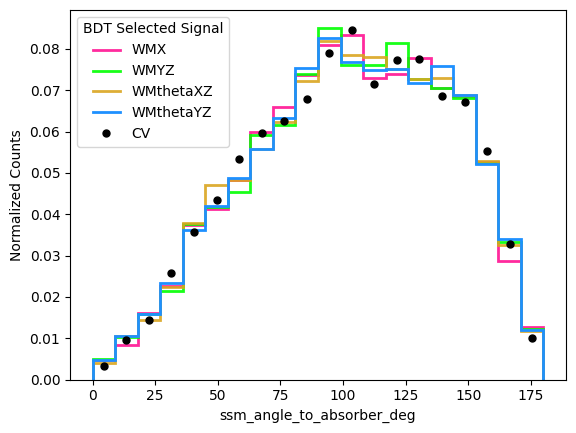

In [30]:
var = 'ssm_angle_to_absorber_deg'
xmin = 0
xmax = 180
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


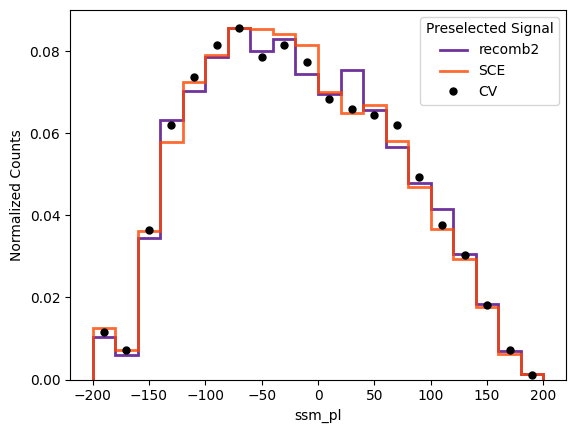

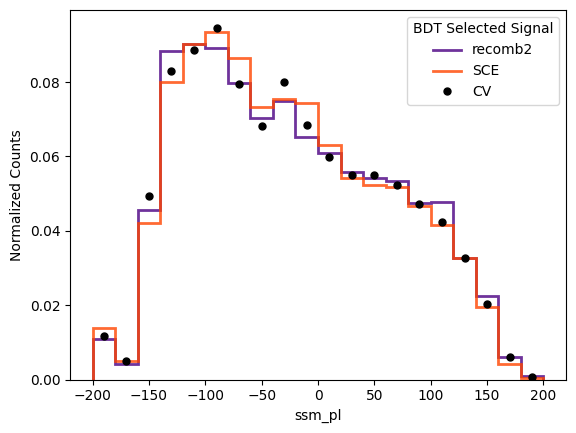

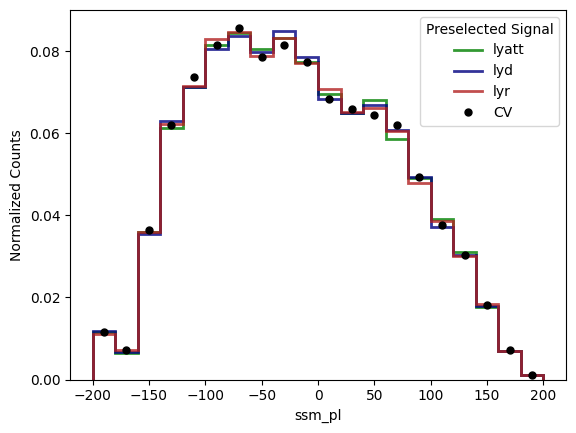

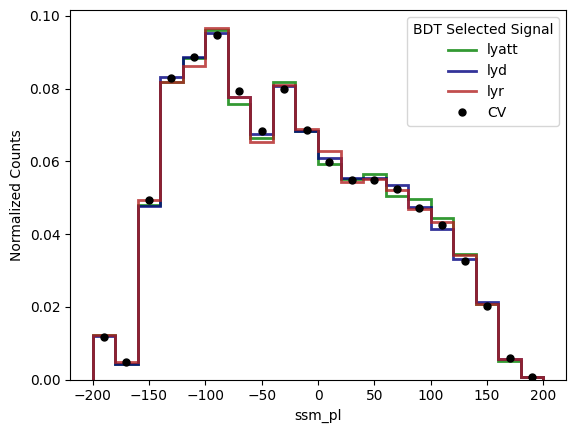

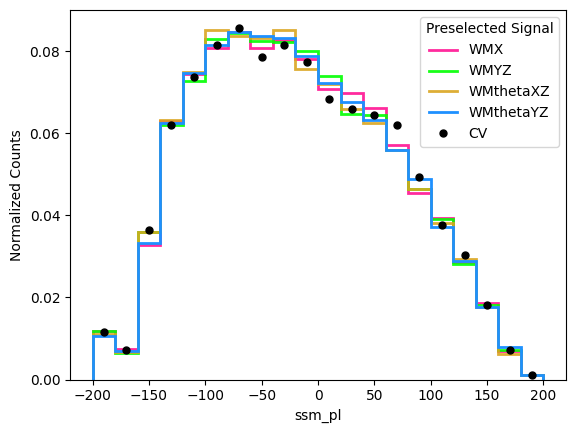

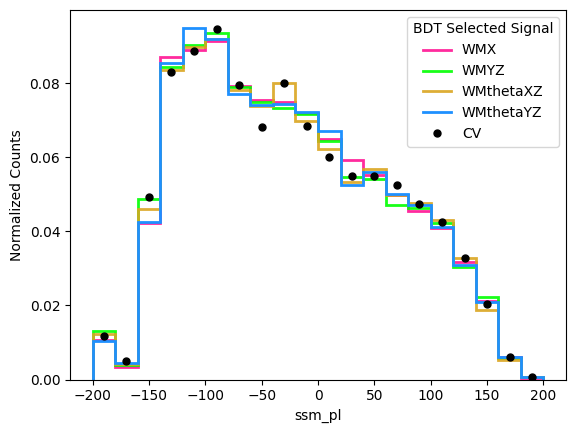

In [31]:
var = 'ssm_pl'
xmin = -200
xmax = 200
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


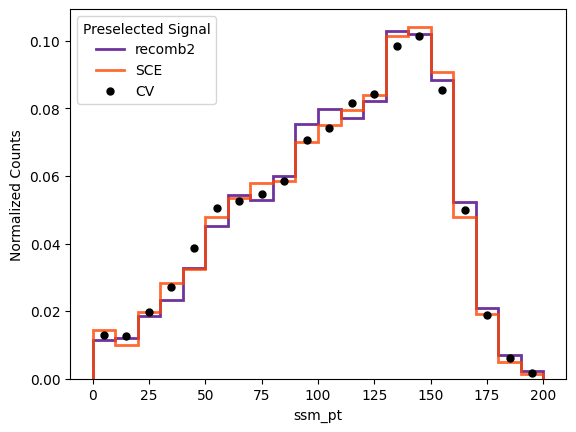

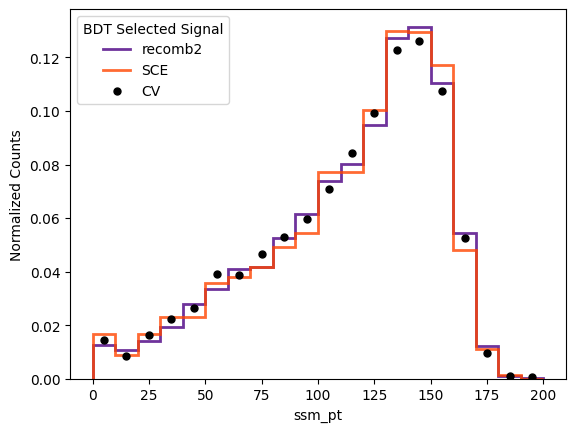

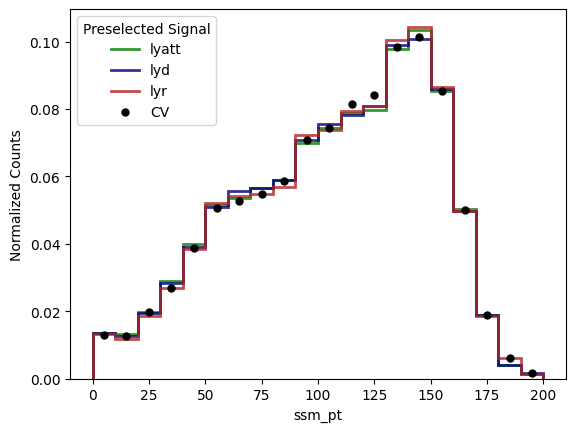

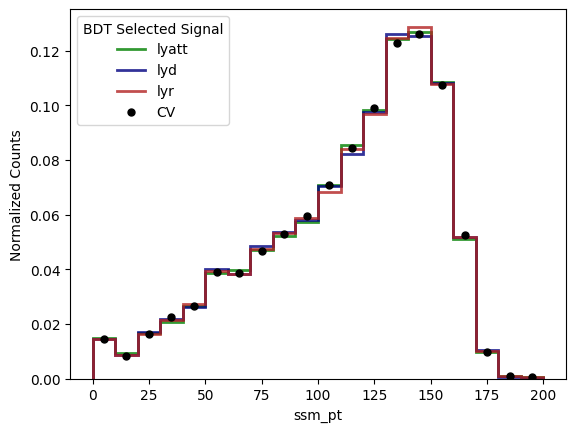

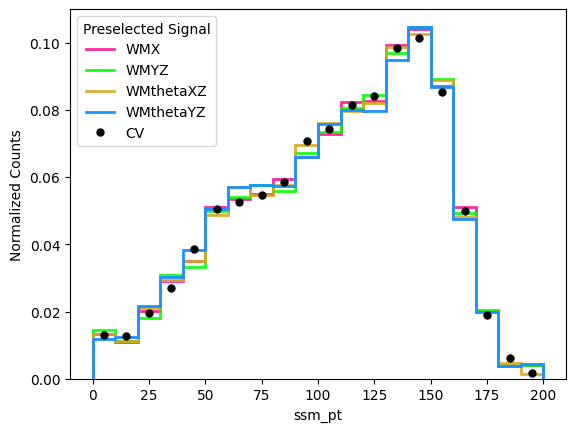

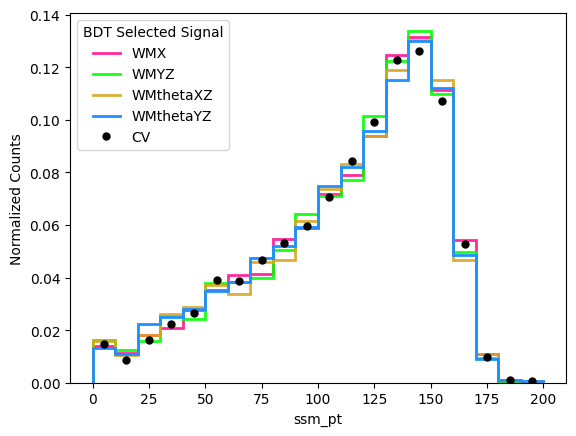

In [32]:
var = 'ssm_pt'
xmin = 0
xmax = 200
nbins = 20

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


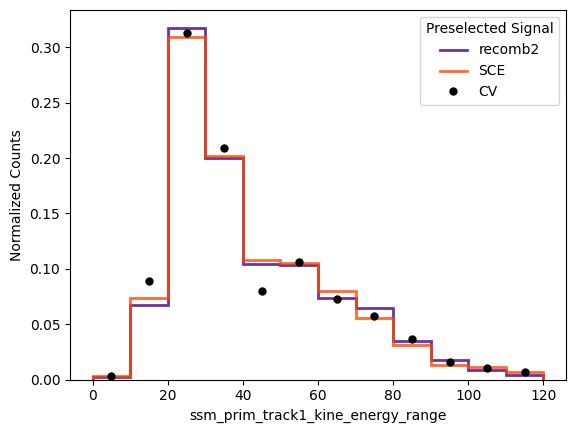

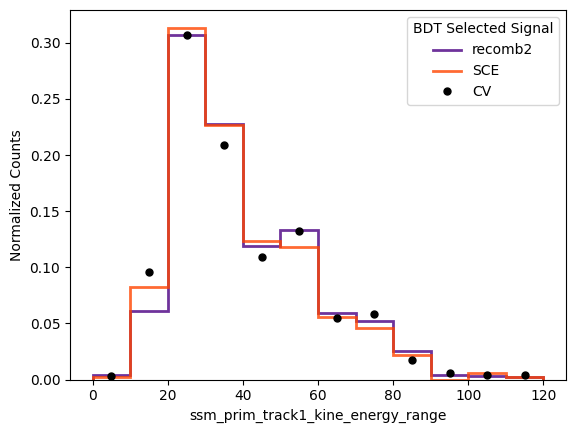

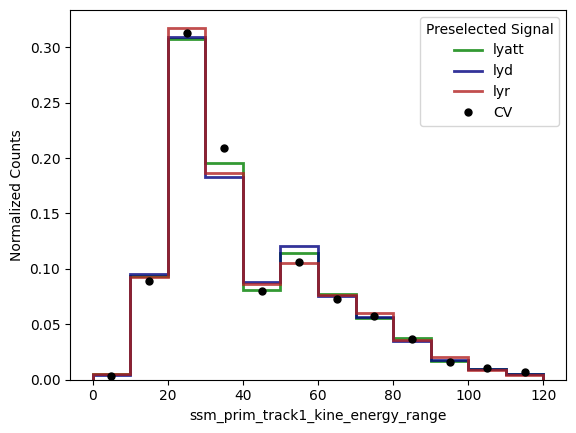

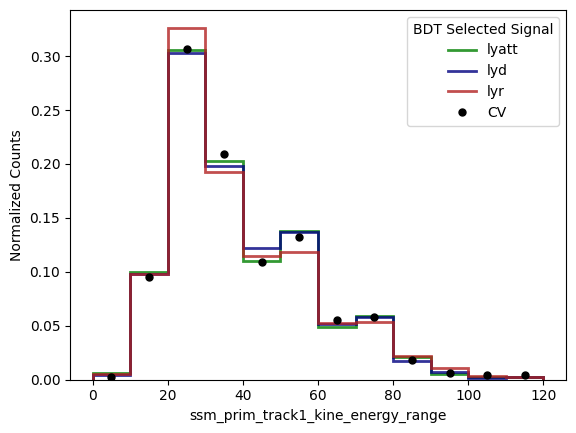

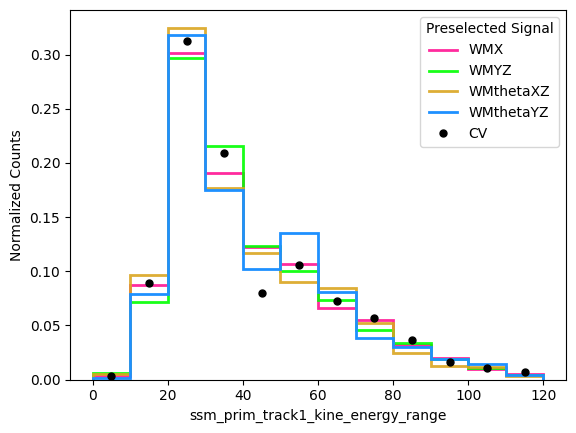

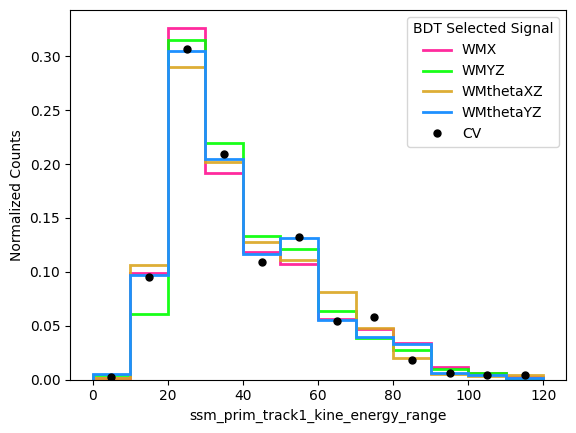

In [33]:
var = 'ssm_prim_track1_kine_energy_range'
xmin = 0
xmax = 120
nbins = 12

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


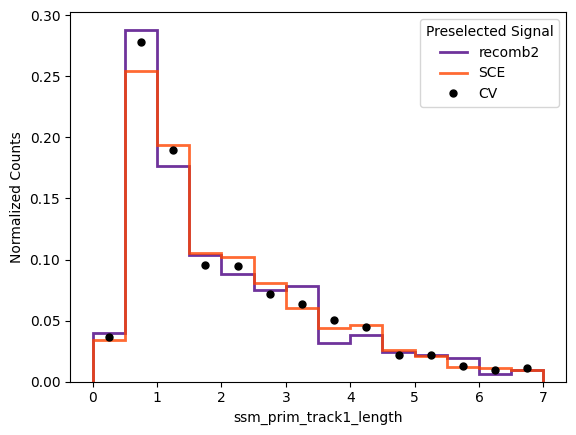

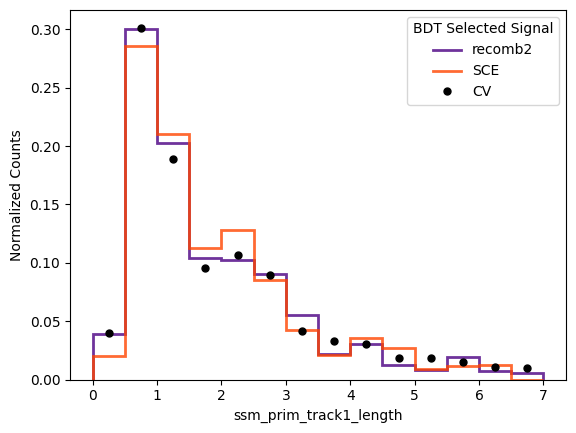

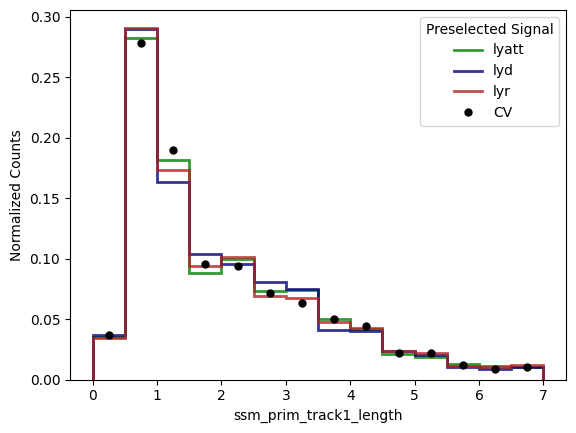

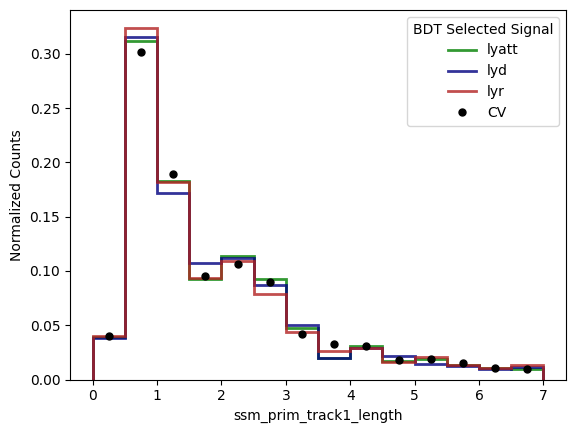

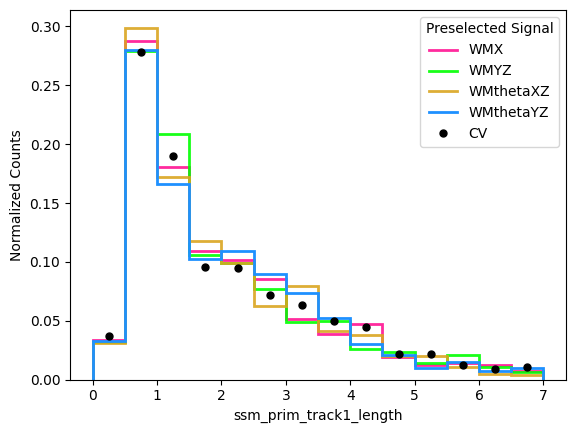

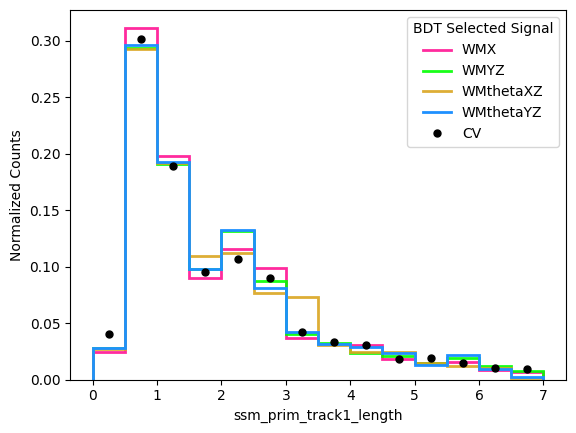

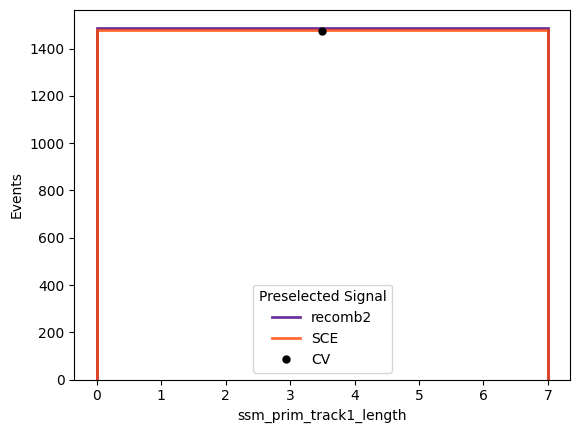

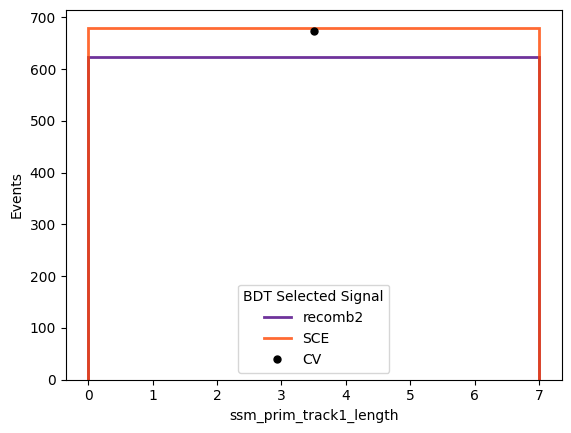

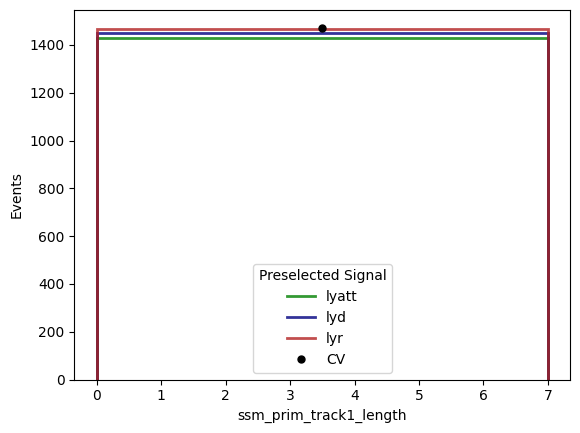

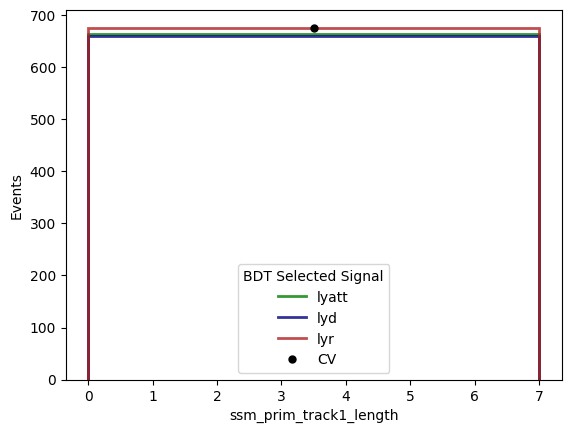

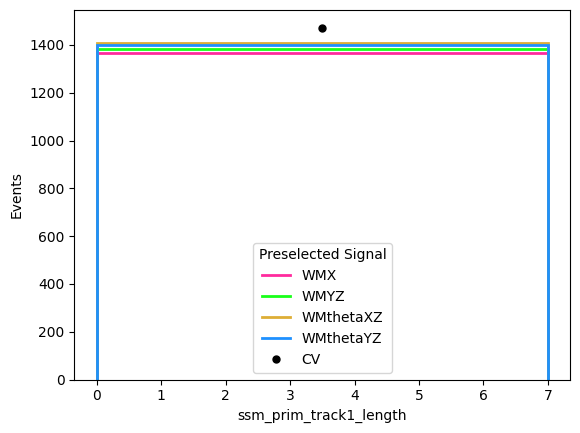

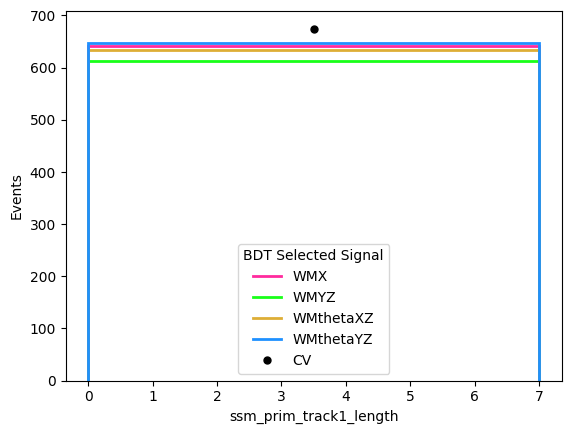

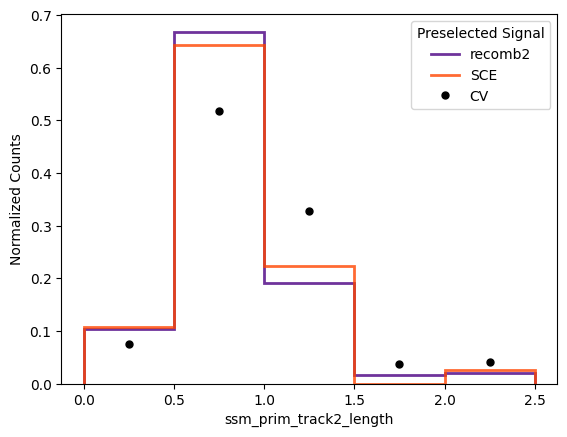

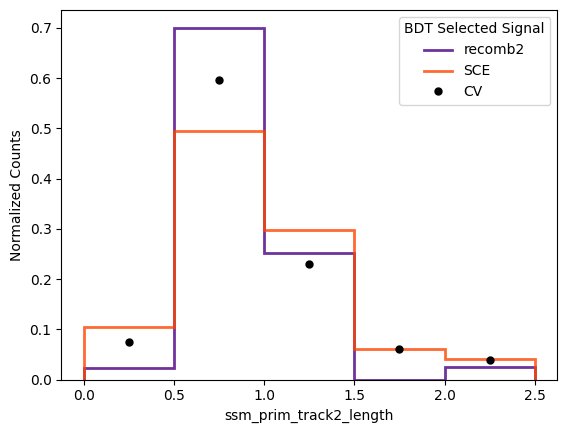

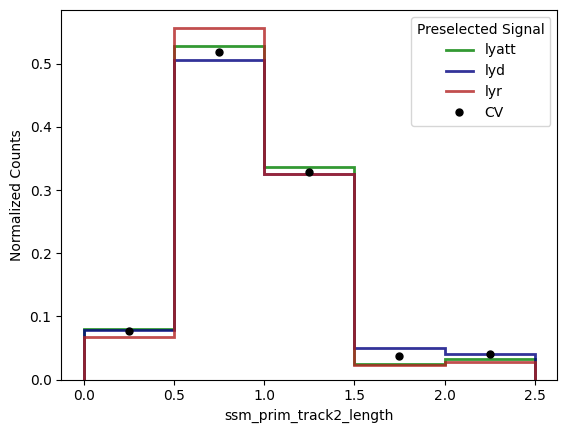

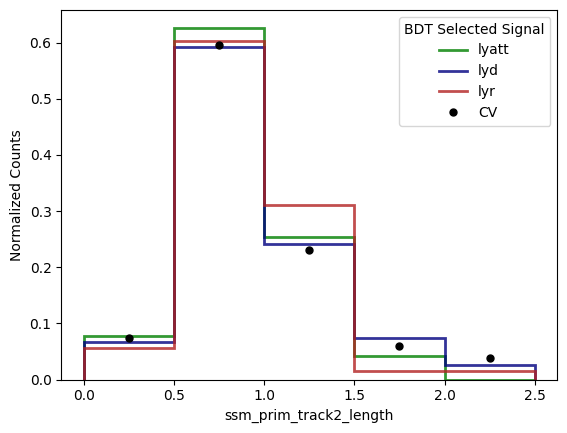

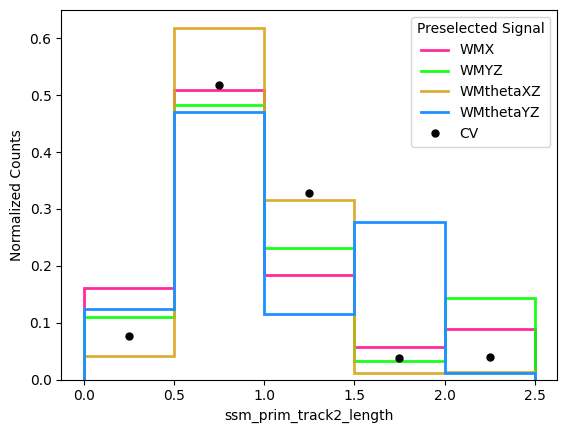

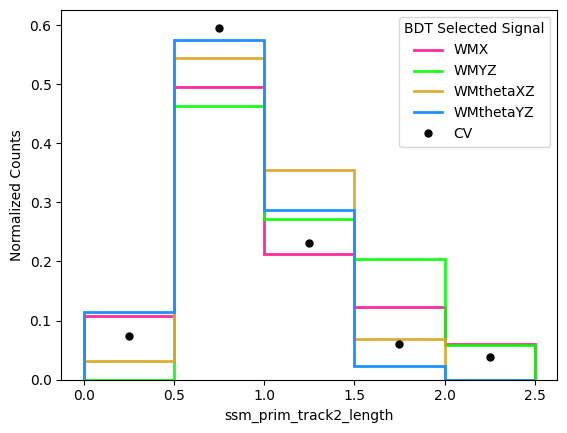

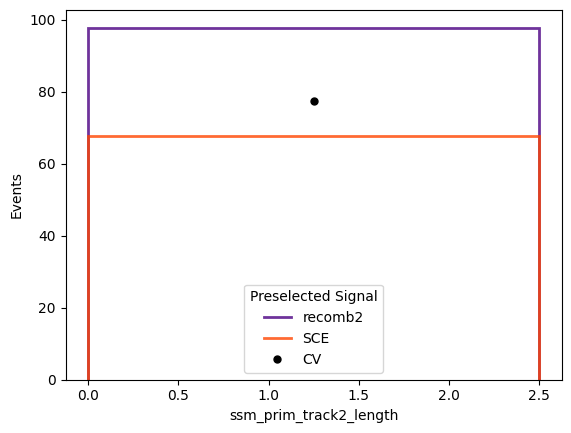

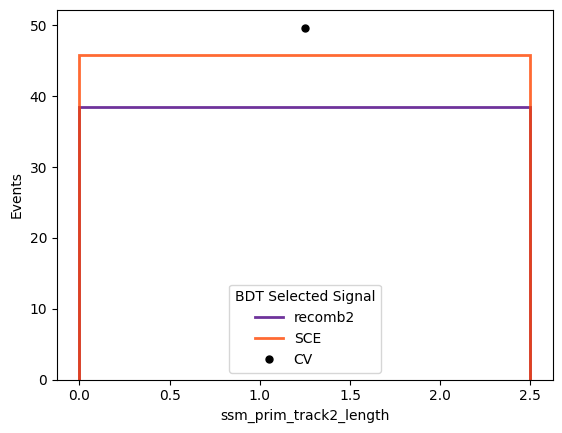

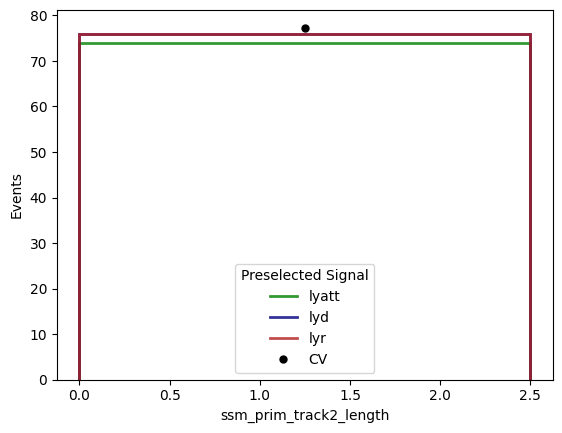

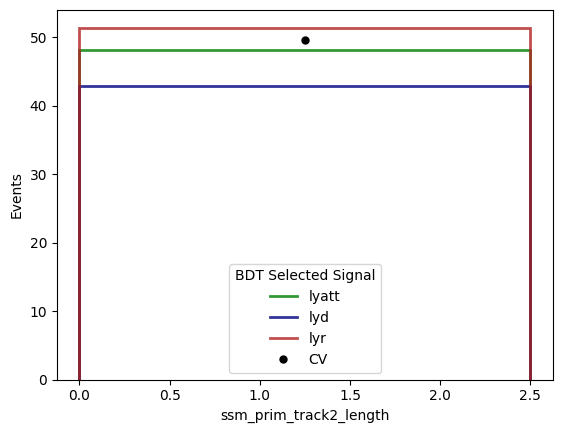

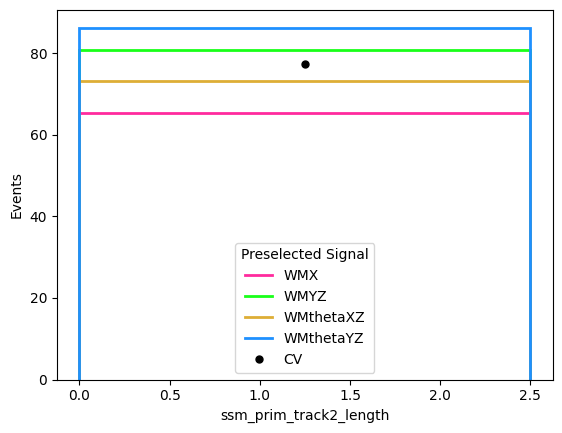

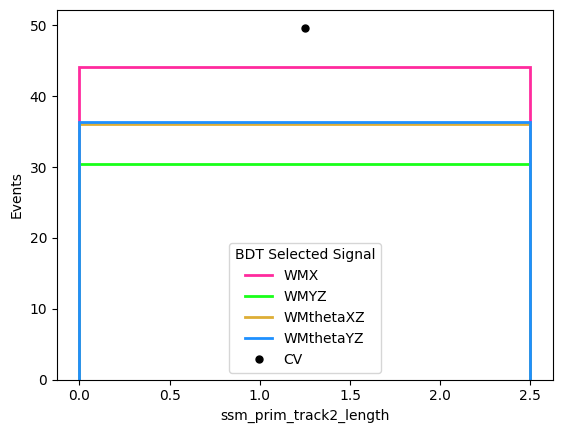

In [34]:
var = 'ssm_prim_track1_length'
xmin = 0
xmax = 7
nbins = 14

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)

nbins = 1
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,norm_sig=False)


var = 'ssm_prim_track2_length'
xmin = 0
xmax = 2.5
nbins = 5

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)

nbins = 1
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,norm_sig=False)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,norm_sig=False)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,norm_sig=False)


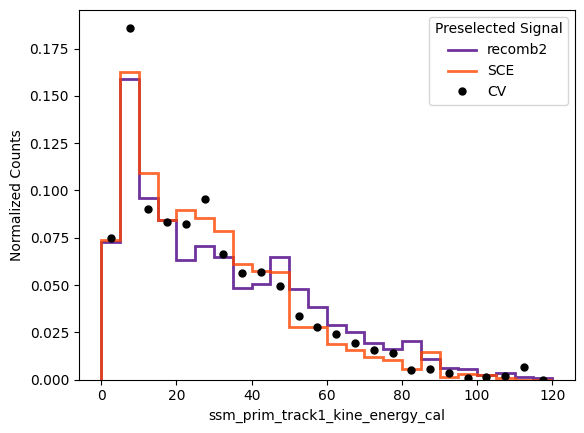

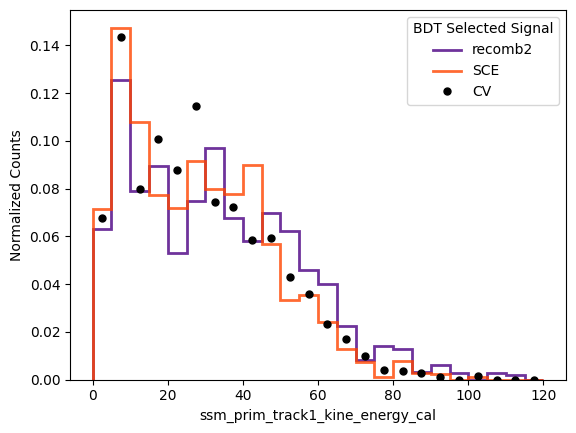

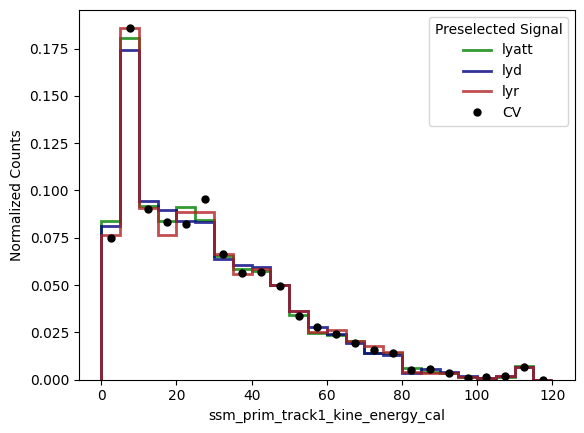

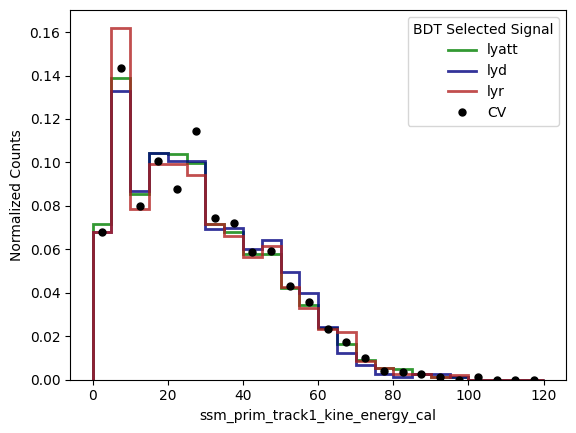

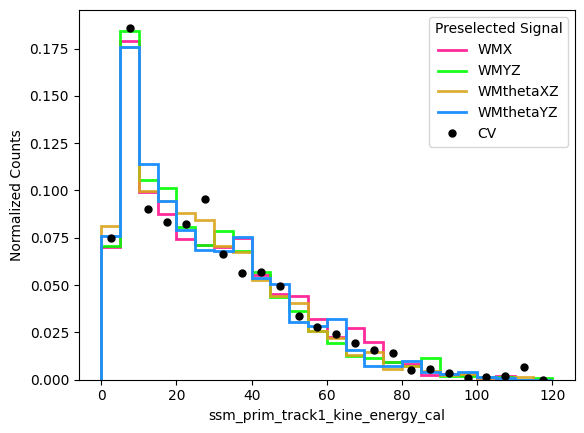

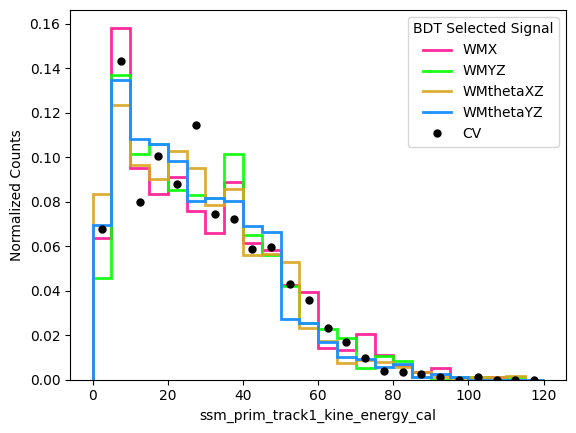

In [35]:
var = 'ssm_prim_track1_kine_energy_cal'
xmin = 0
xmax = 120
nbins = 24

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


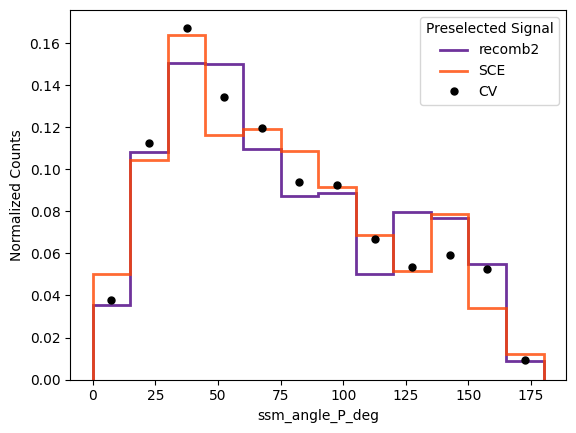

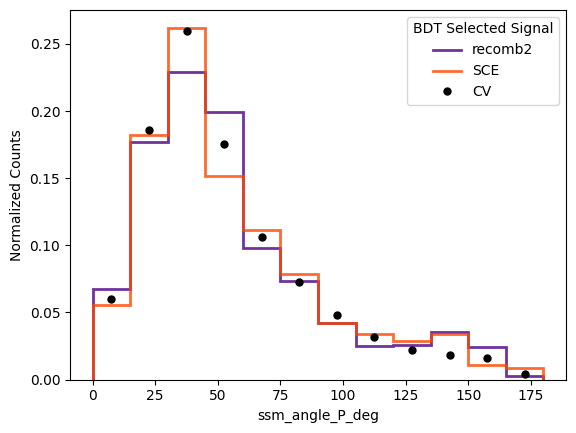

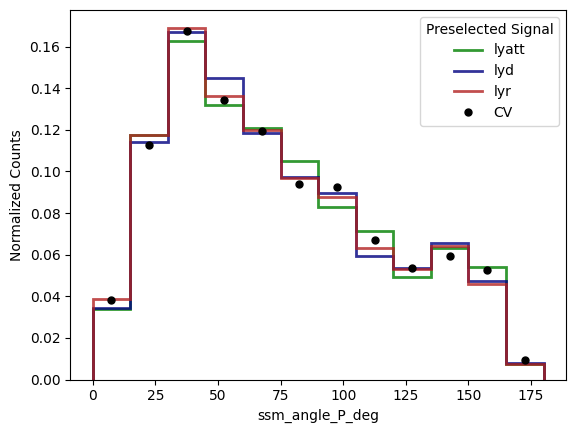

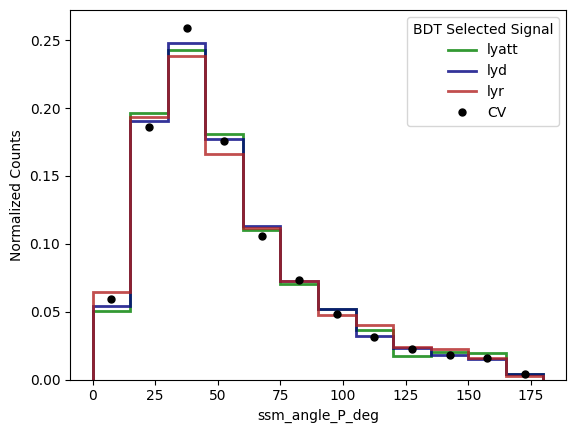

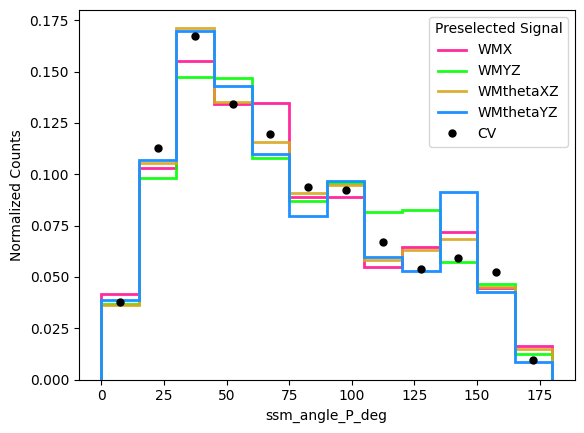

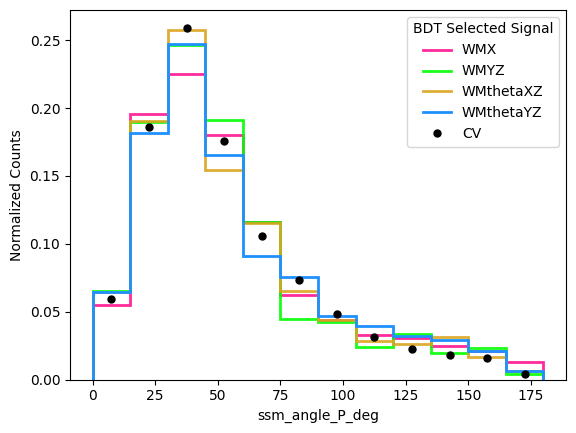

In [36]:
var = 'ssm_angle_P_deg'
xmin = 0
xmax = 180
nbins = 12
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=False,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


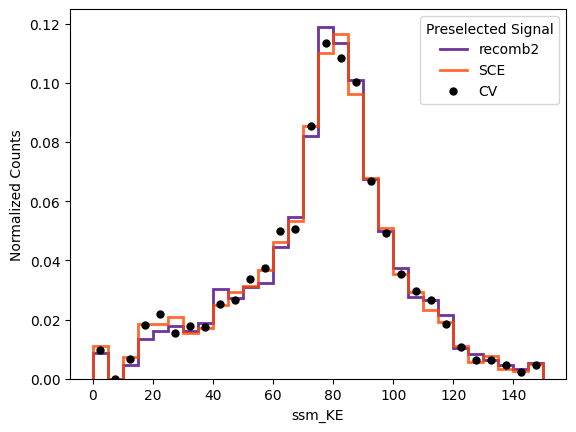

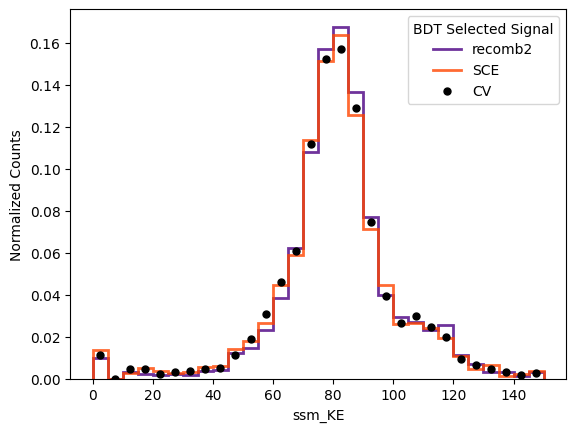

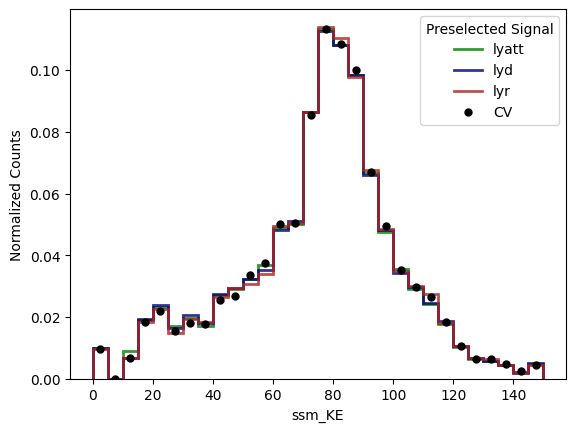

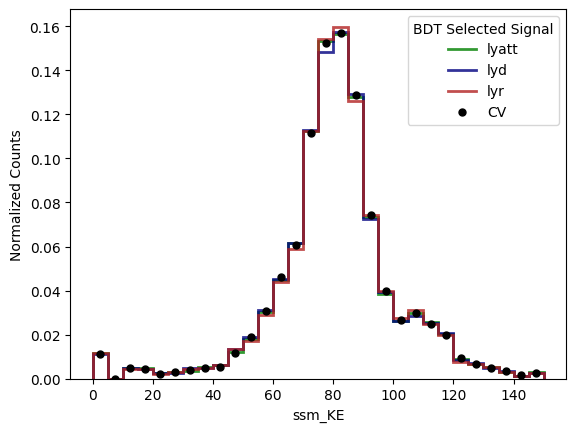

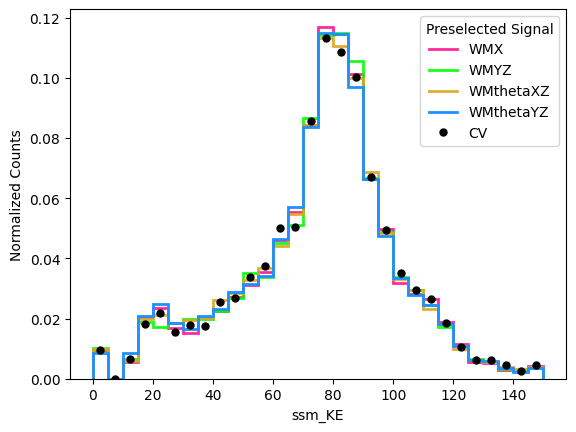

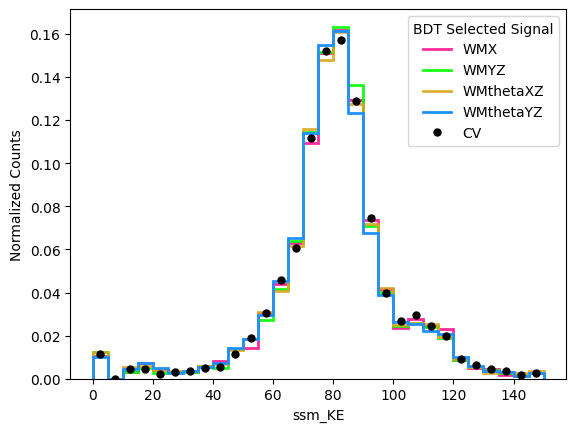

In [37]:
var = 'ssm_KE'
xmin = 0
xmax = 150
nbins = 30

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


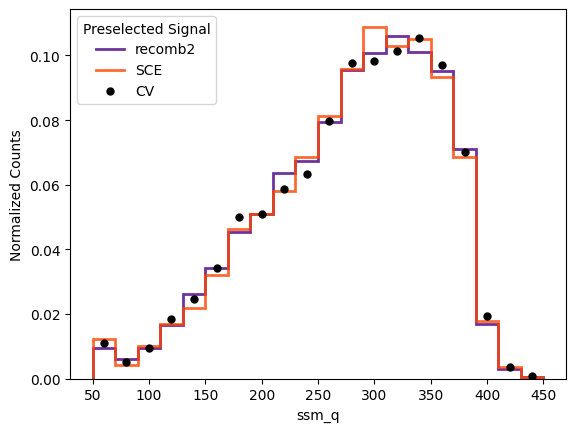

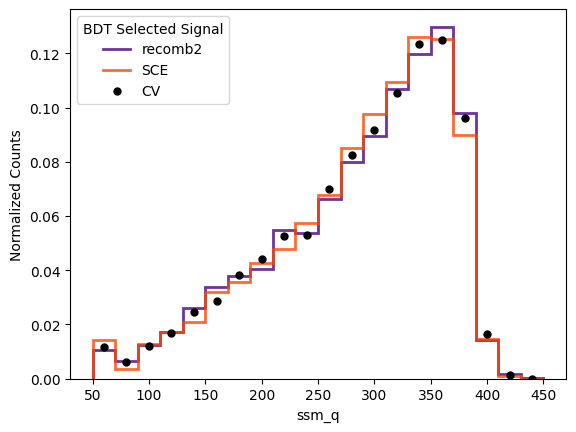

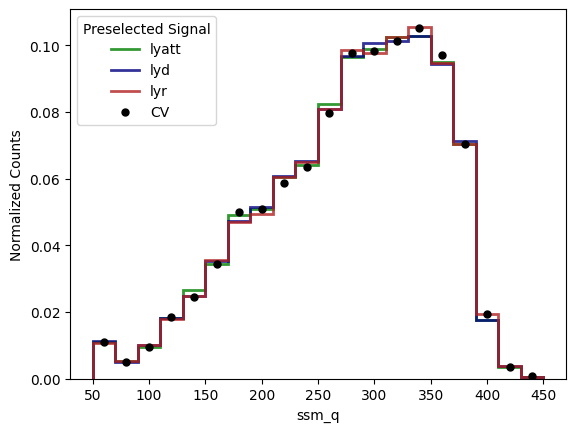

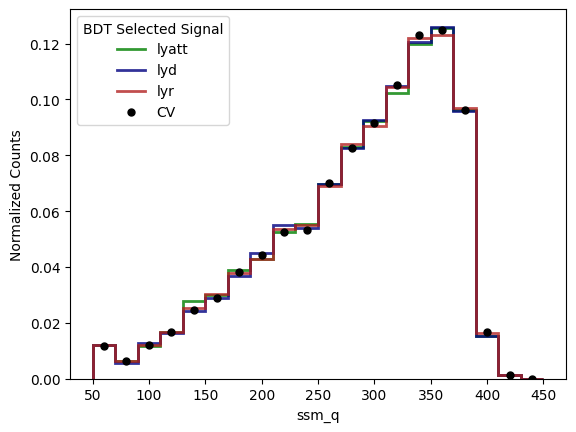

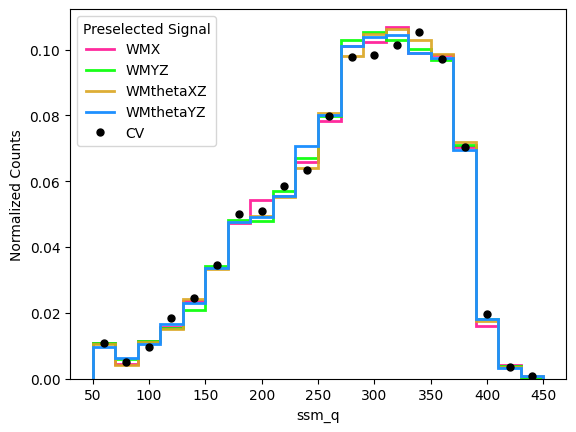

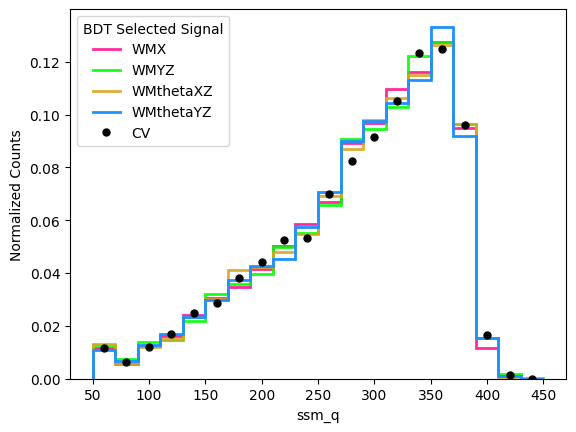

In [38]:
var = 'ssm_q'
xmin = 50
xmax = 450
nbins = 20

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


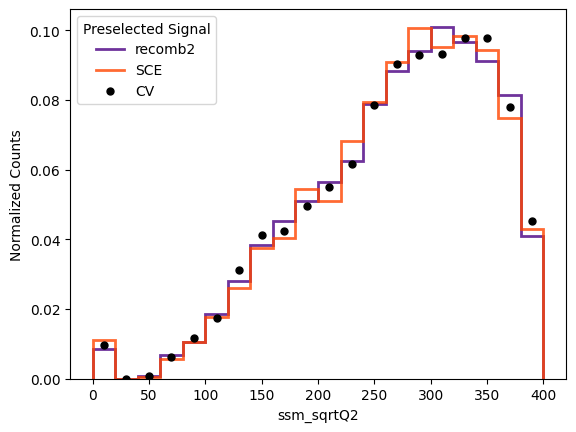

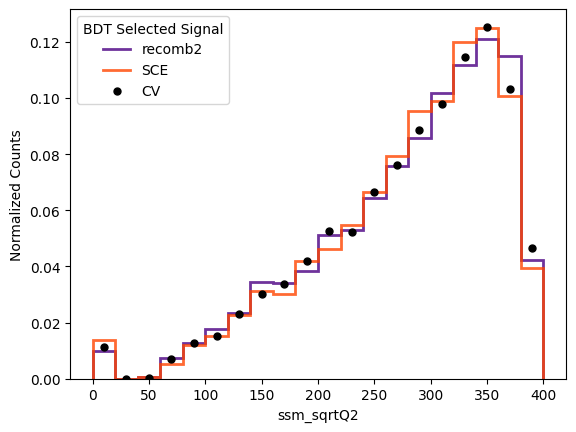

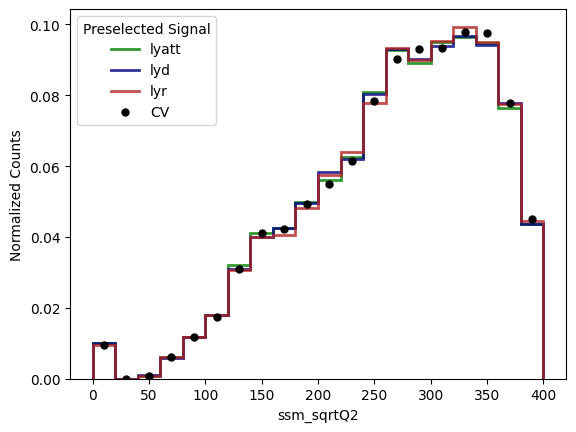

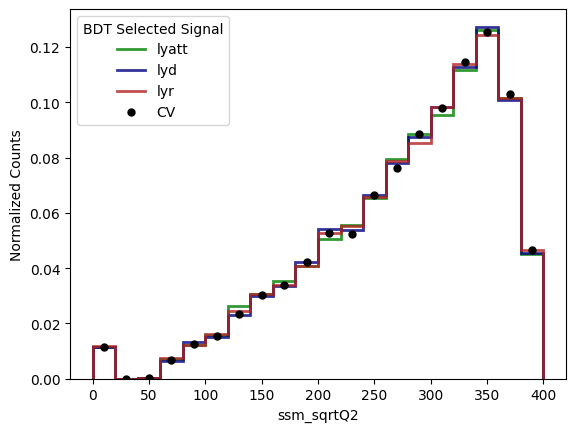

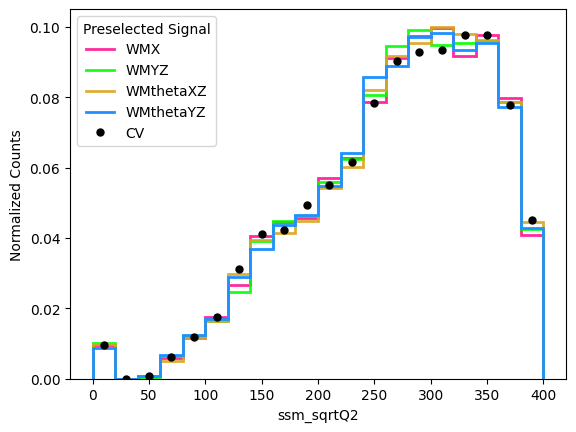

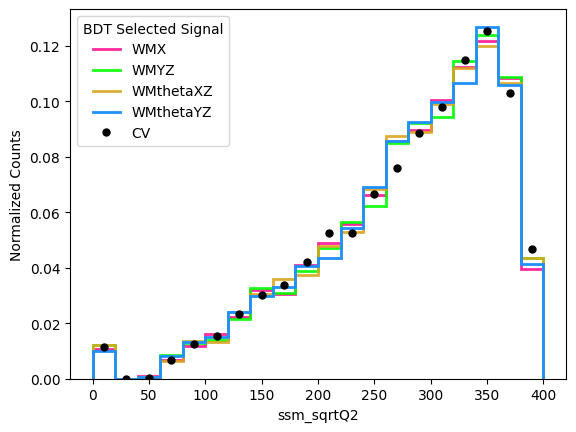

In [39]:
var = 'ssm_sqrtQ2'
xmin = 0
xmax = 400
nbins = 20

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)


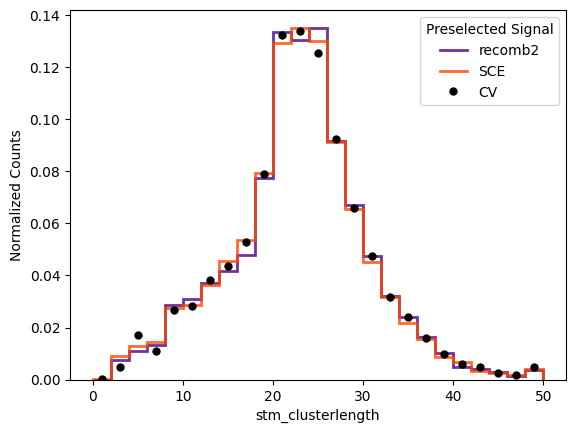

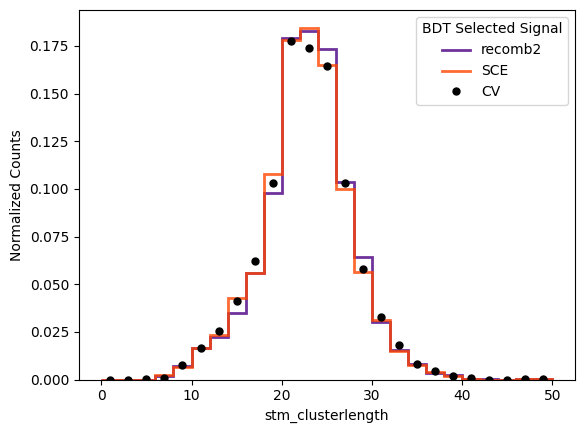

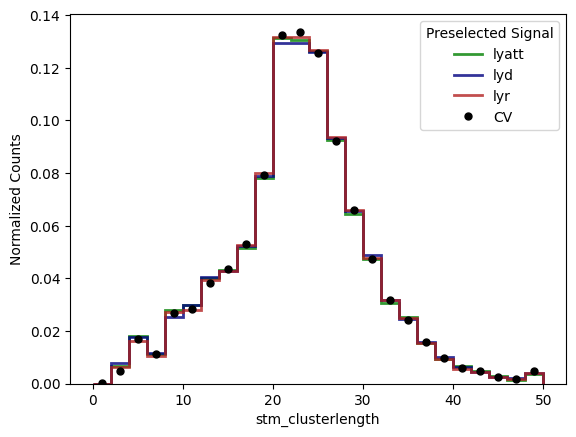

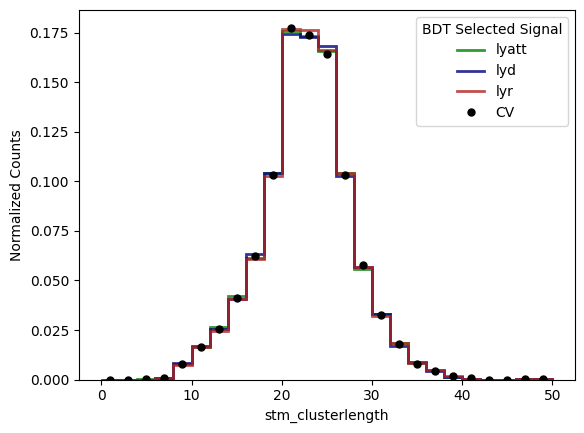

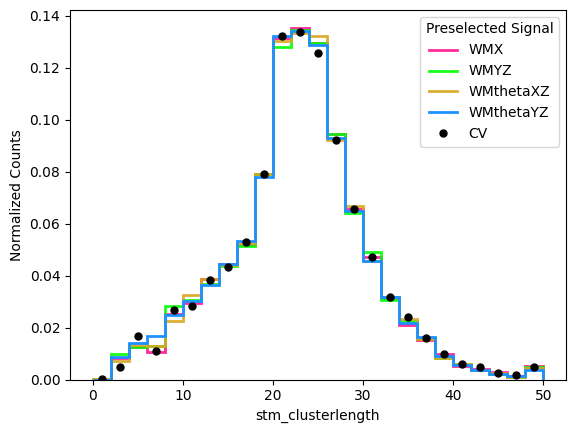

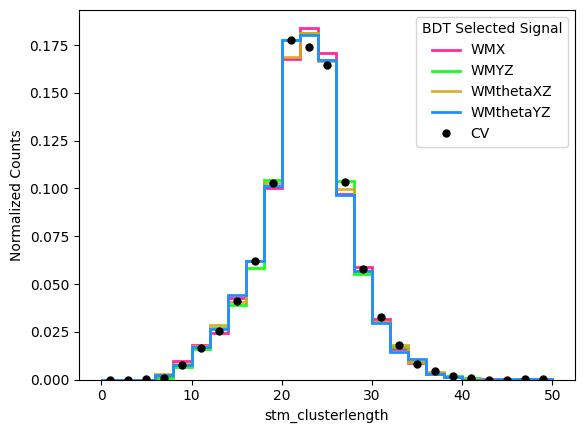

In [23]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 25

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)




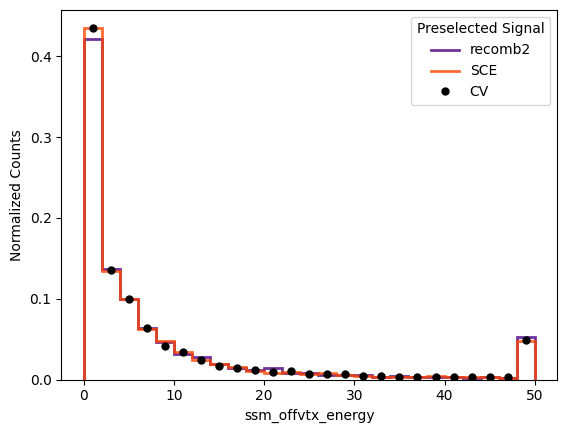

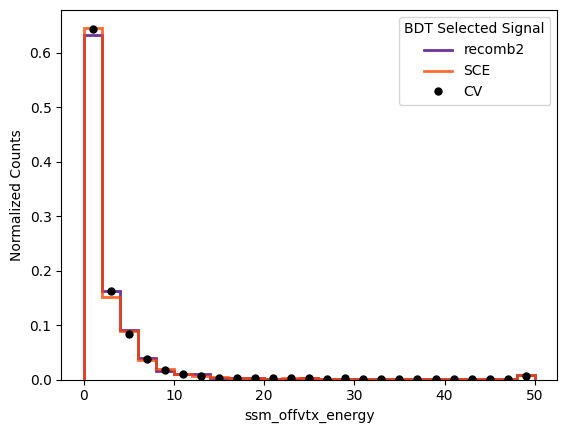

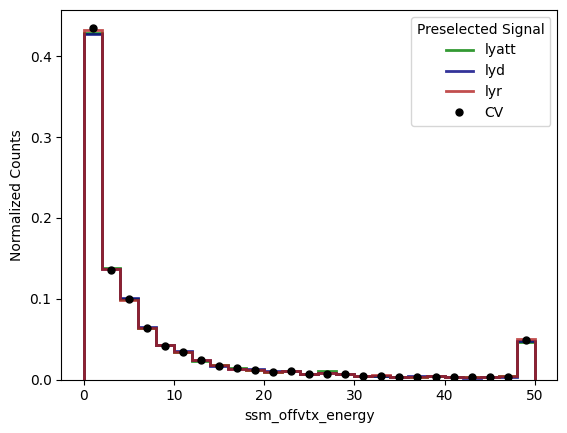

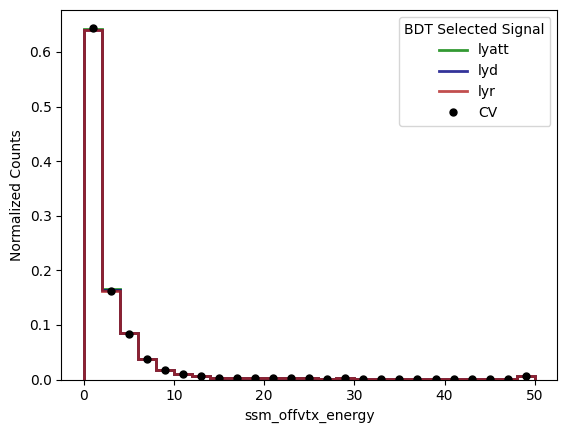

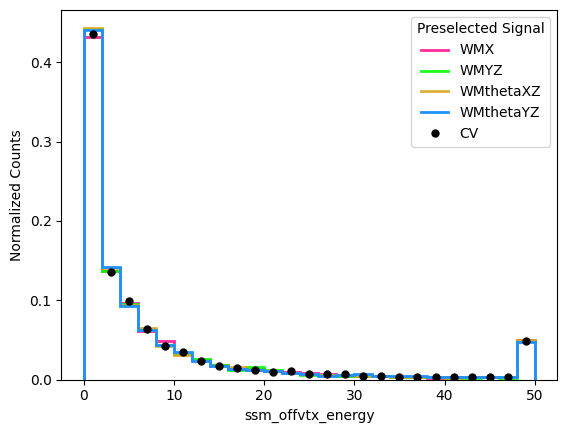

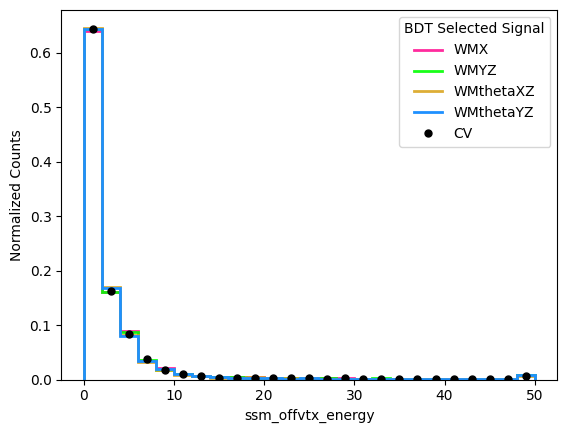

In [24]:
var = 'ssm_offvtx_energy'
xmin = 0
xmax = 50
nbins = 25

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



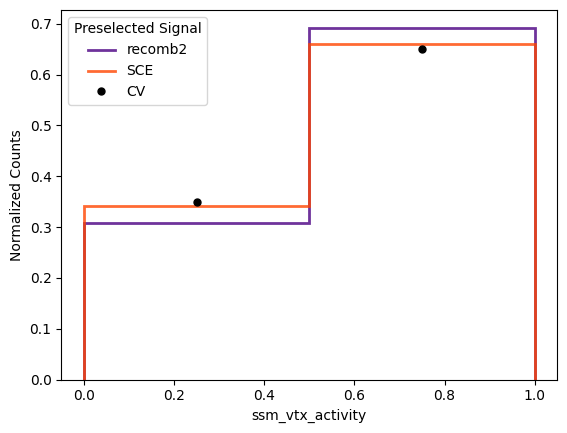

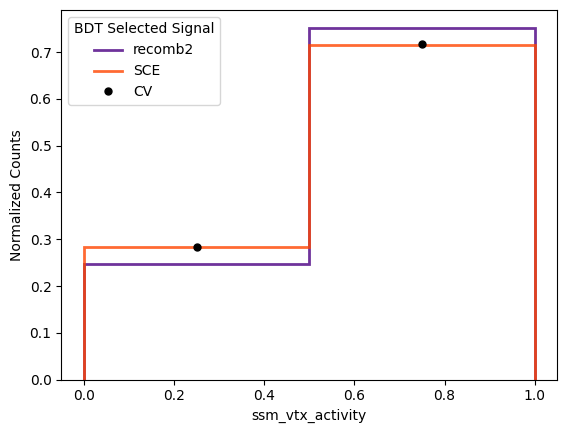

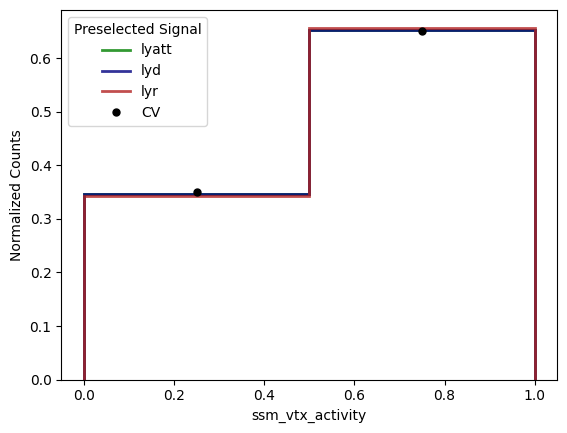

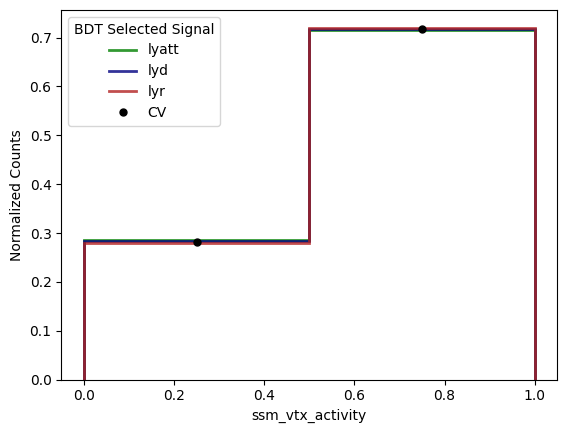

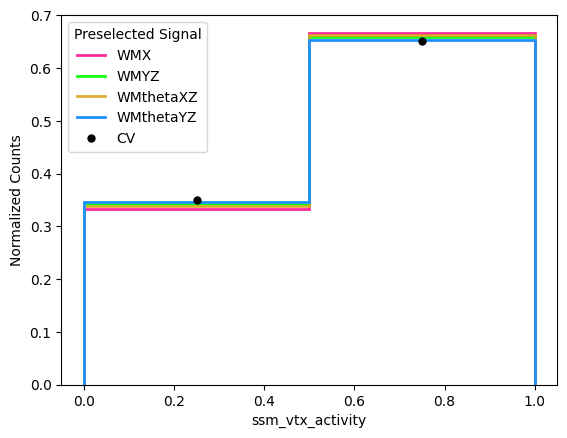

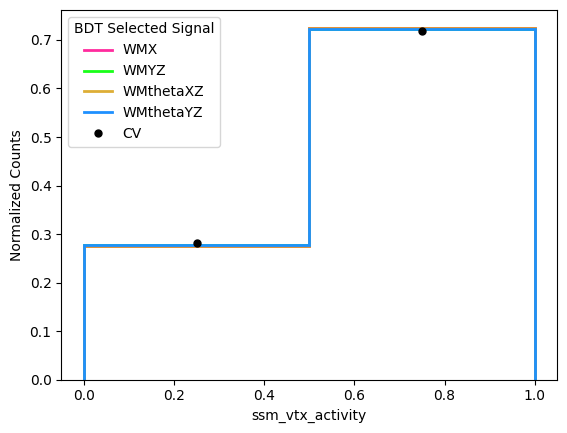

In [25]:
var = 'ssm_vtx_activity'
xmin = 0
xmax = 1
nbins = 2
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



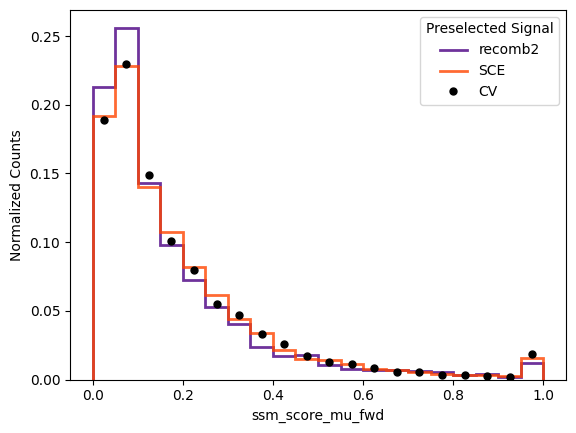

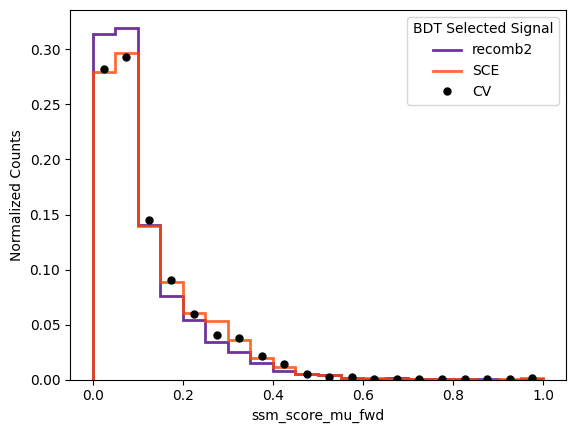

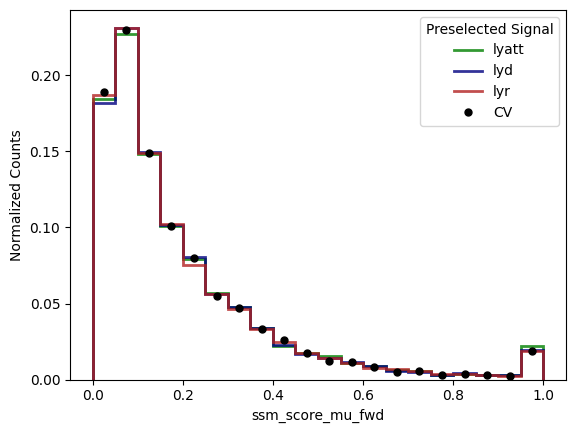

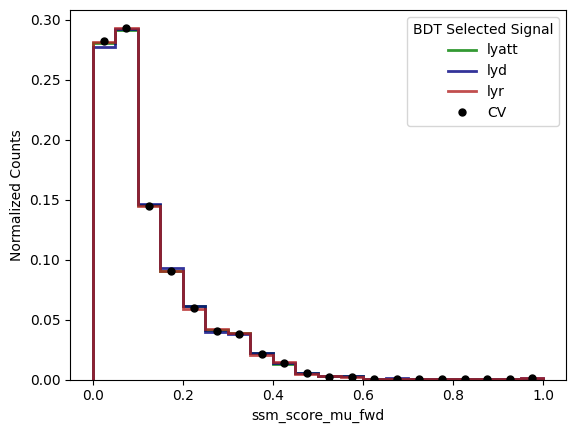

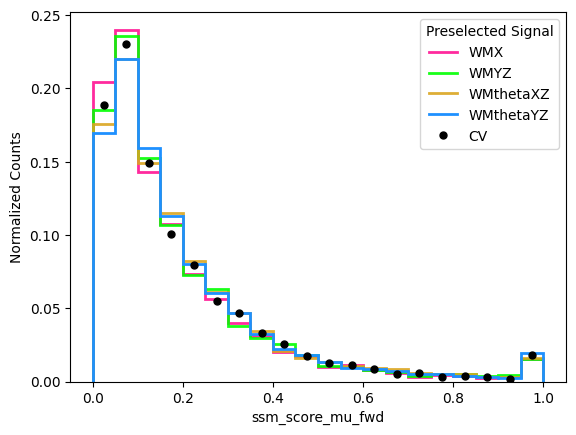

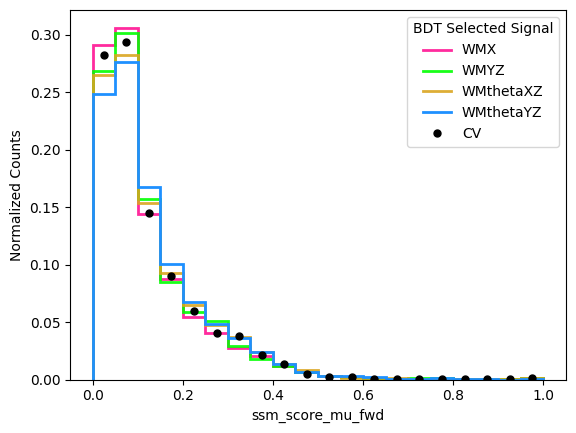

In [26]:
var = 'ssm_score_mu_fwd'
xmin = 0
xmax = 1
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



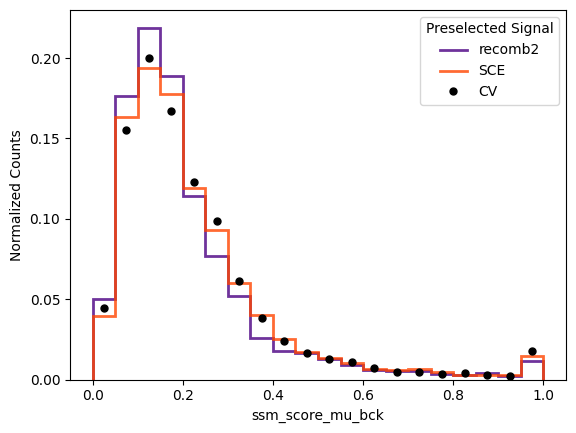

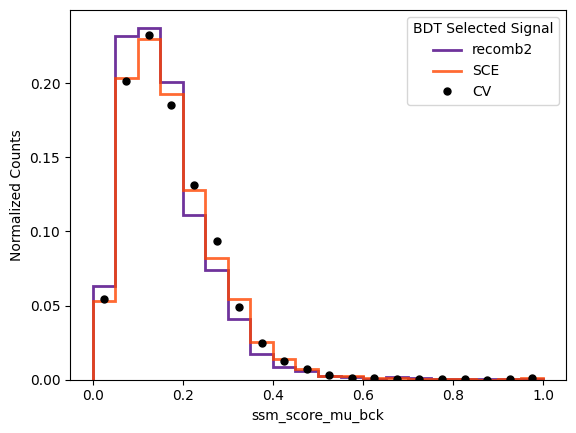

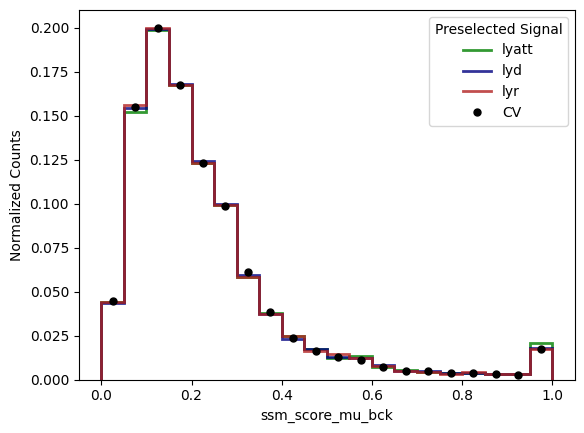

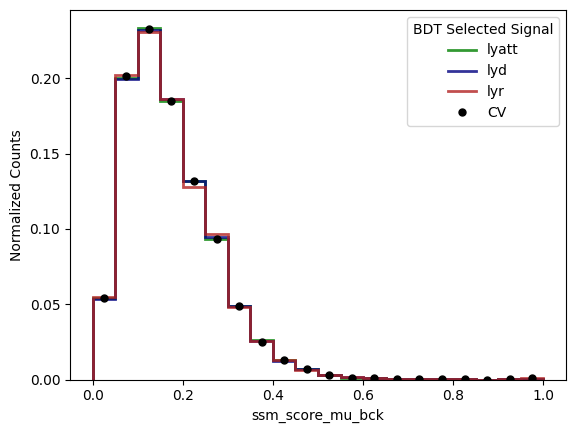

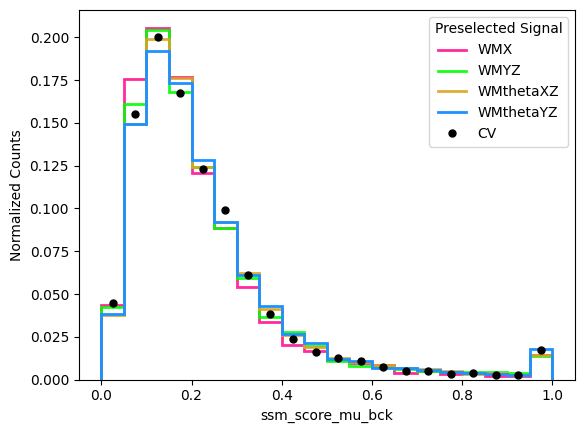

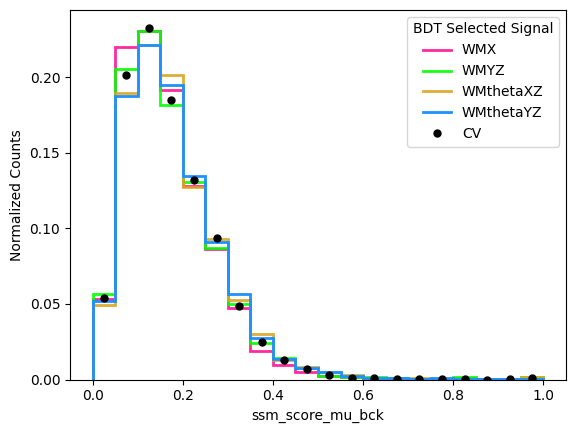

In [27]:
var = 'ssm_score_mu_bck'
xmin = 0
xmax = 1
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



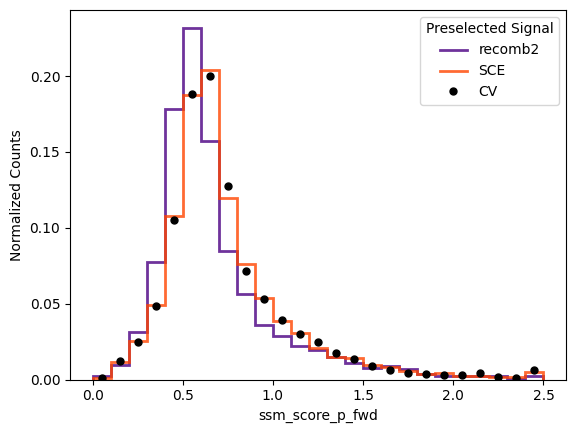

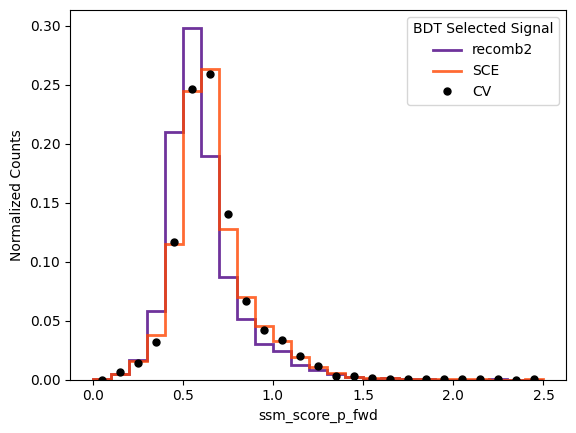

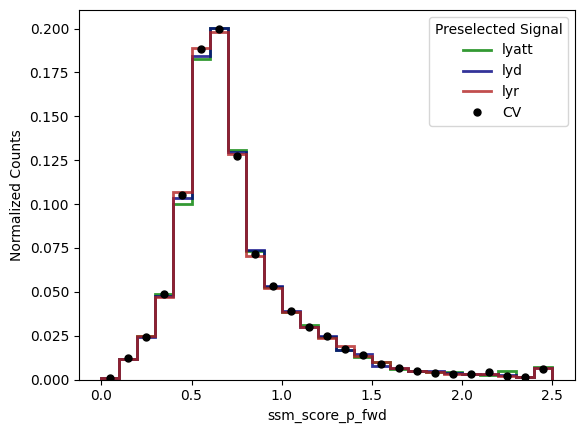

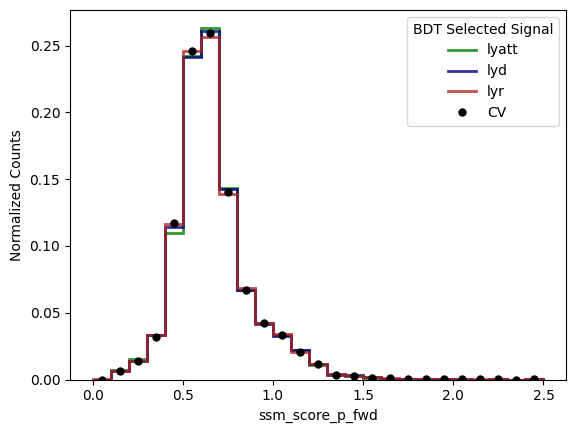

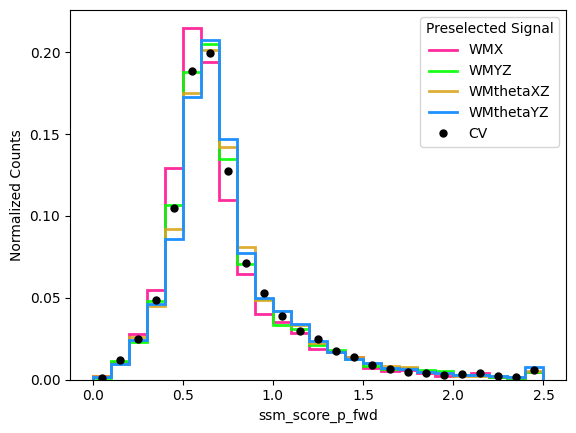

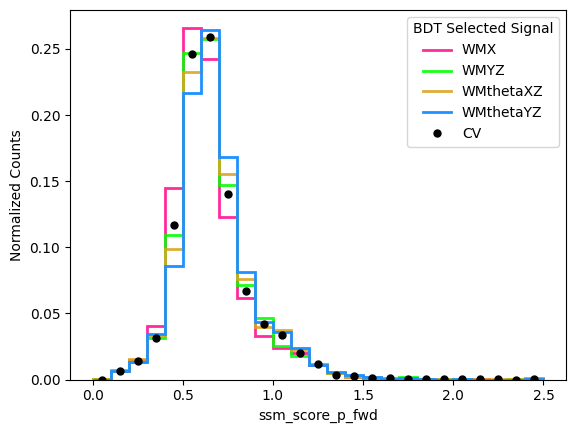

In [28]:
var = 'ssm_score_p_fwd'
xmin = 0
xmax = 2.5
nbins = 25
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



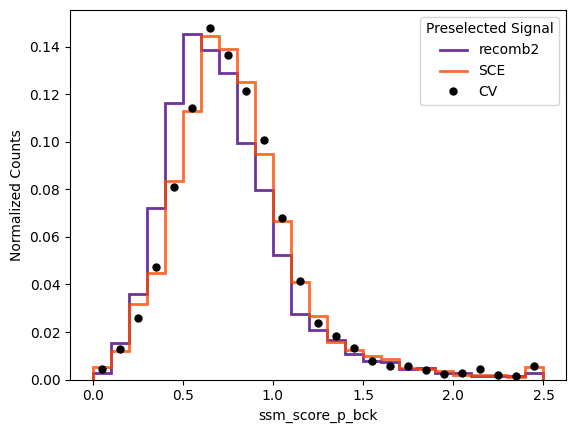

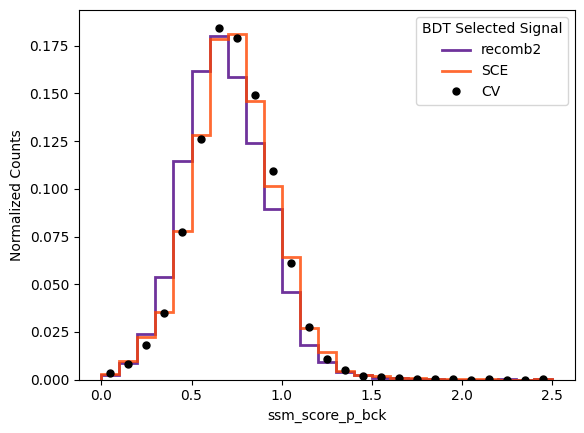

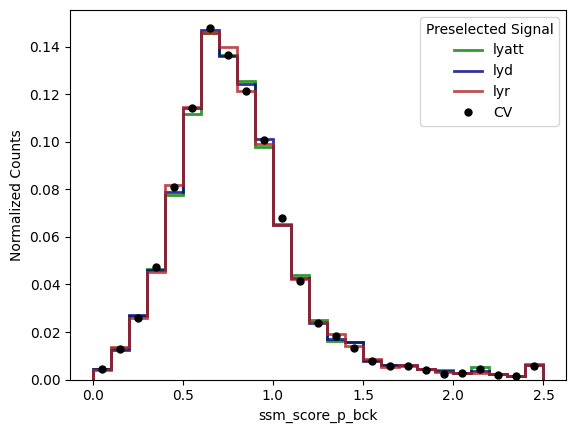

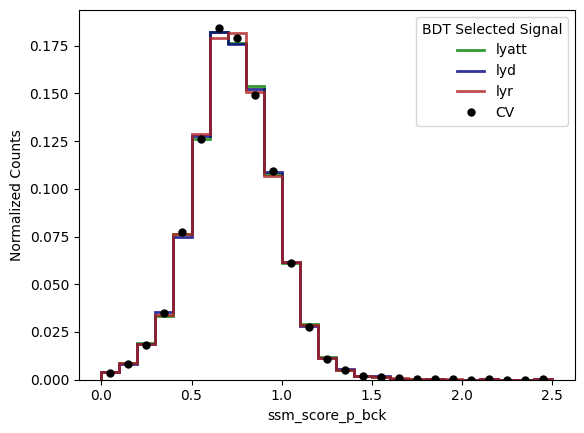

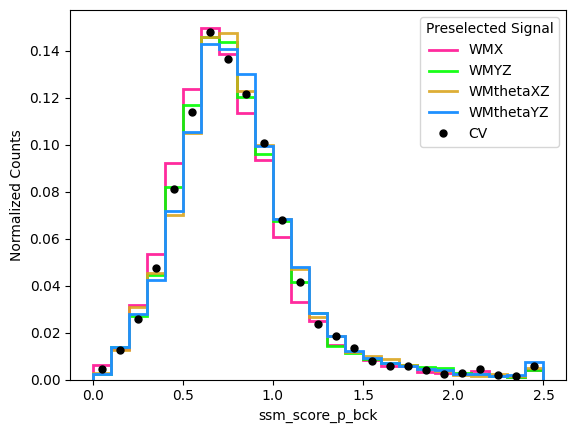

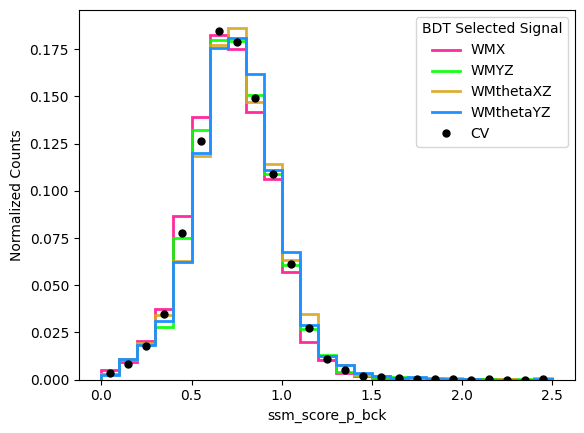

In [29]:
var = 'ssm_score_p_bck'
xmin = 0
xmax = 2.5
nbins = 25
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



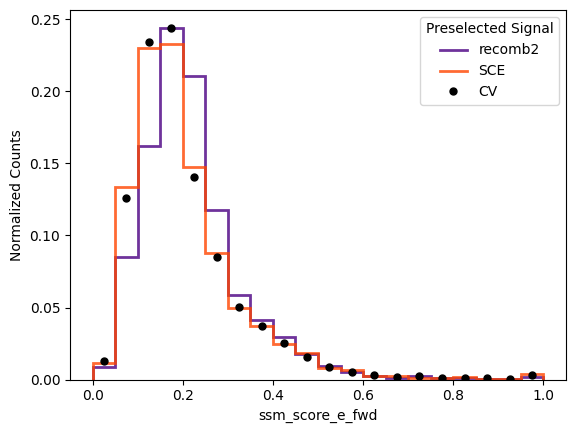

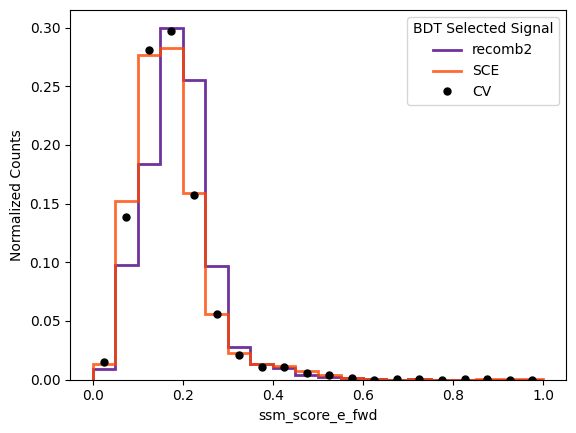

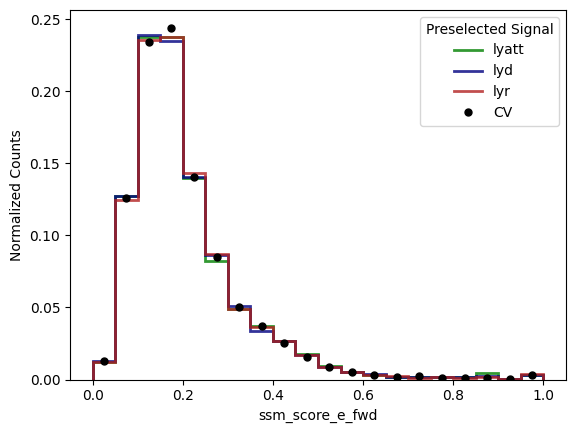

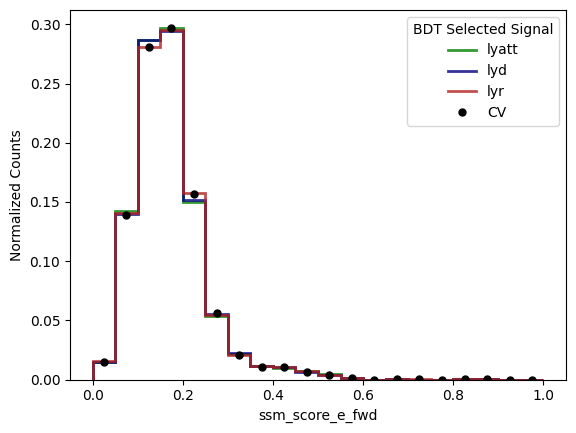

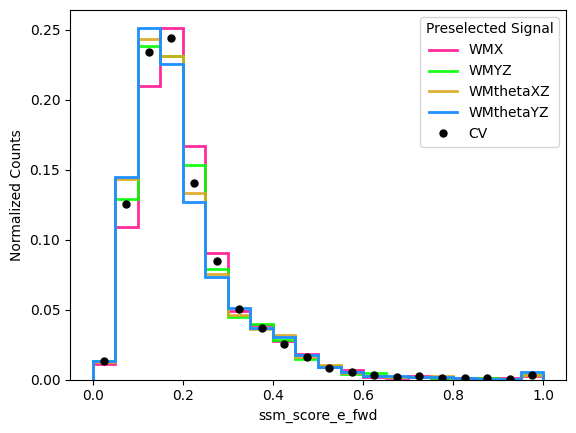

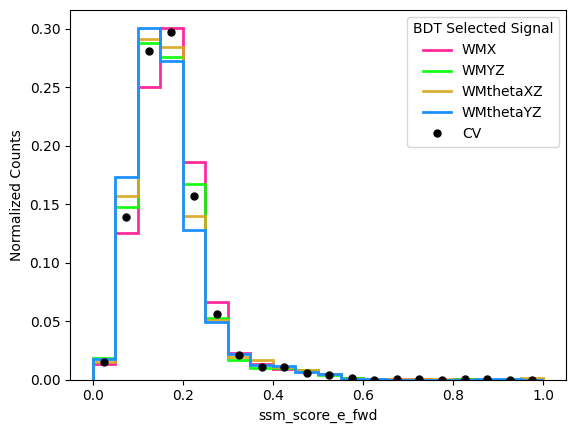

In [30]:
var = 'ssm_score_e_fwd'
xmin = 0
xmax = 1
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



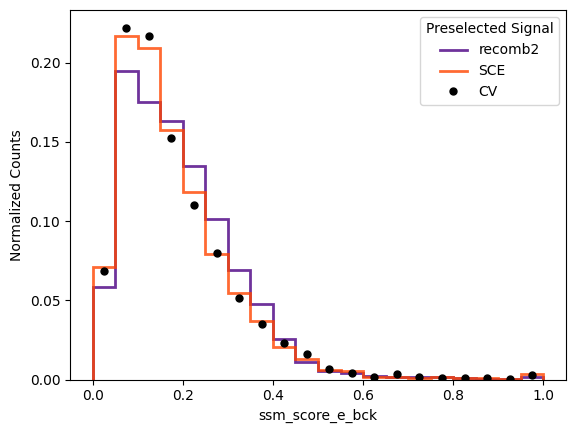

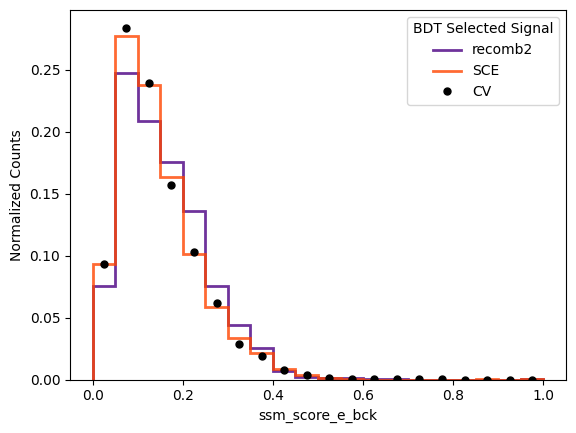

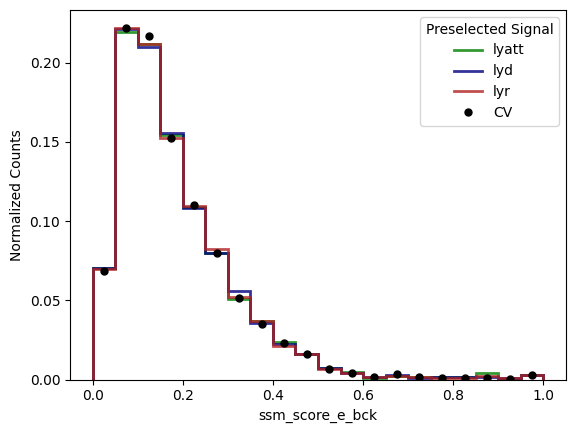

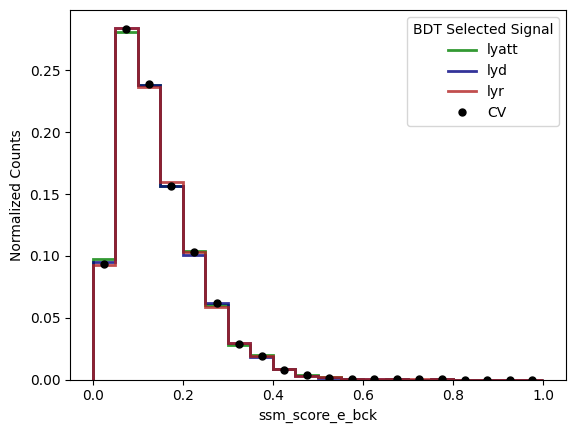

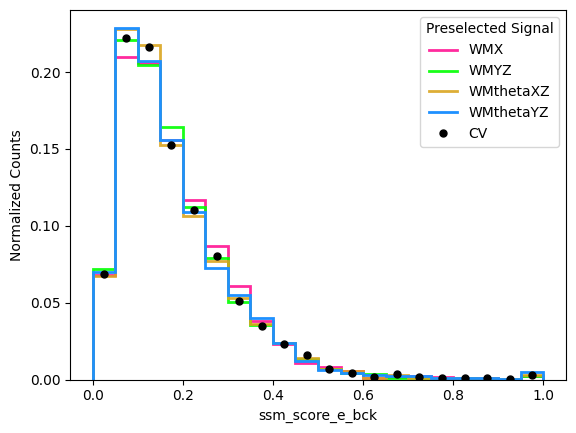

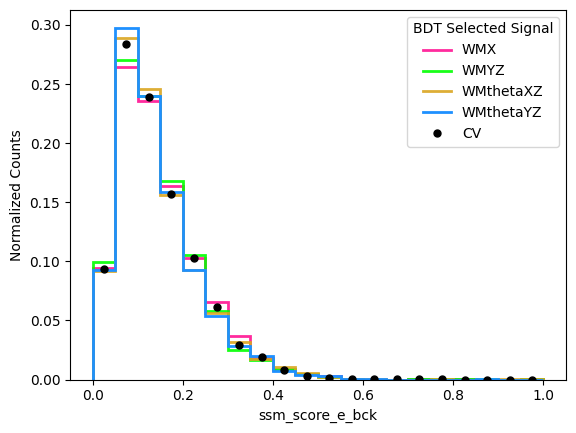

In [31]:
var = 'ssm_score_e_bck'
xmin = 0
xmax = 1
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



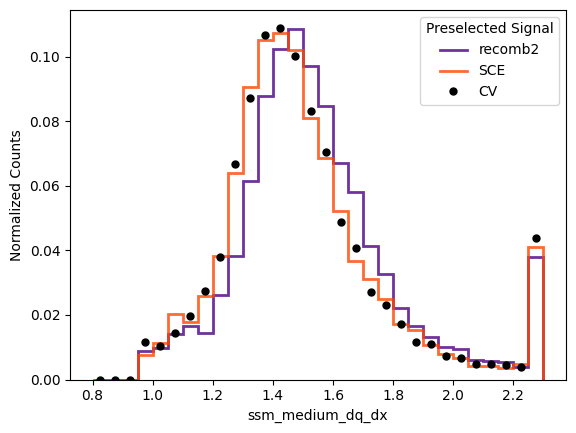

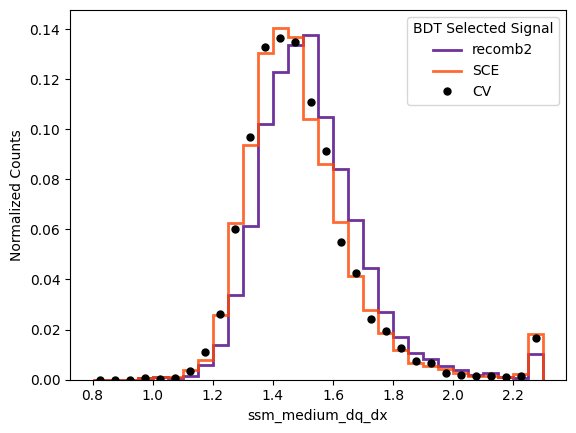

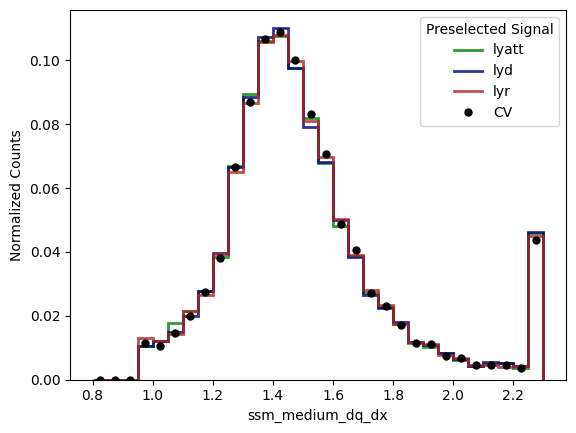

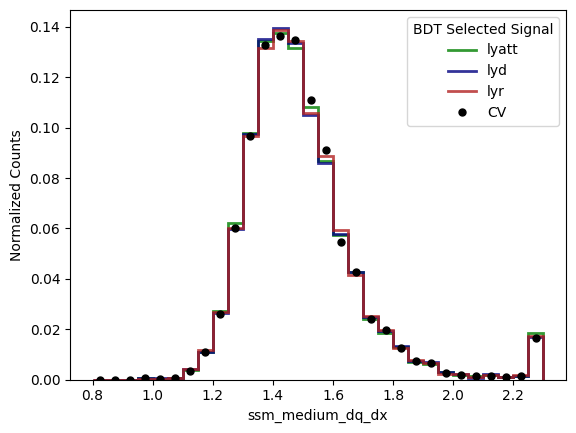

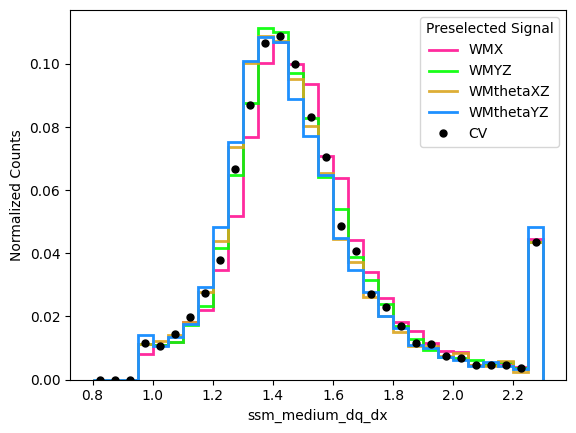

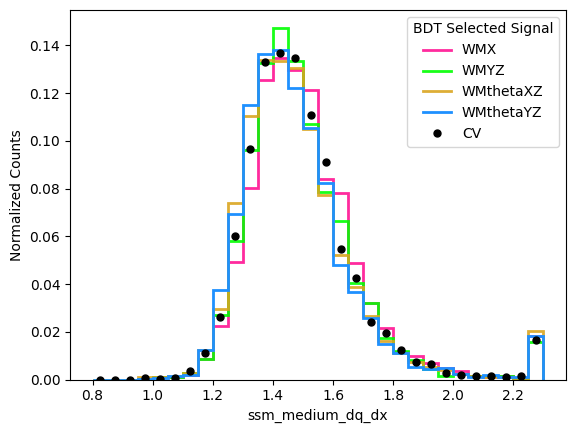

In [32]:
var = 'ssm_medium_dq_dx'
xmin = 0.8
xmax = 2.3
nbins = 30
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



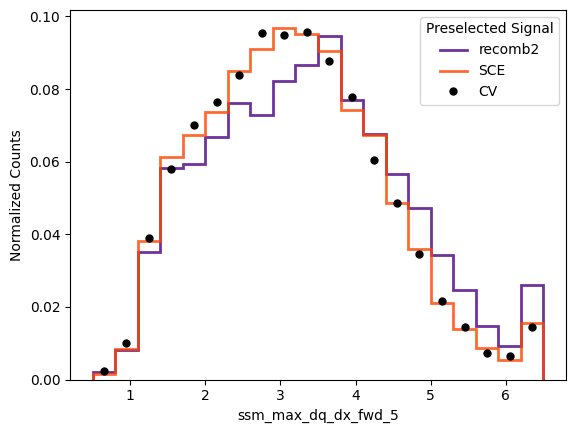

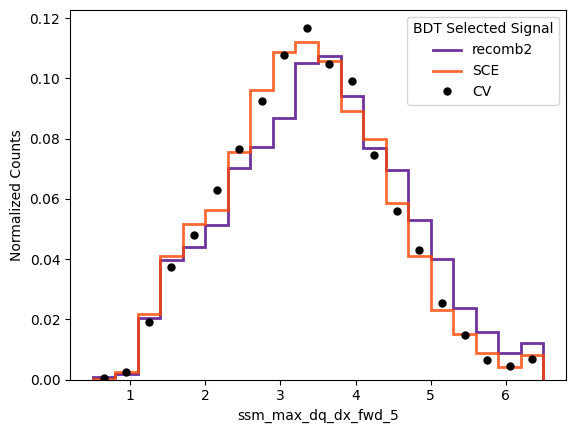

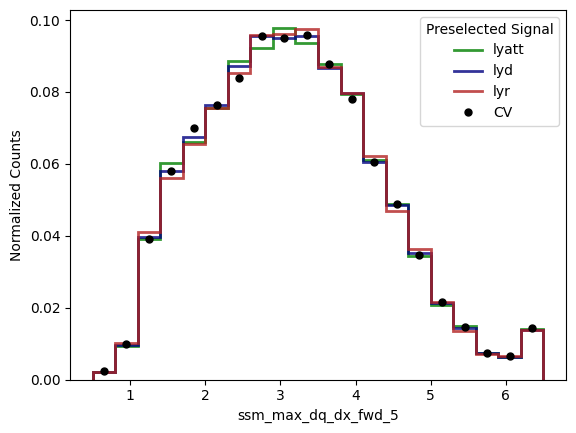

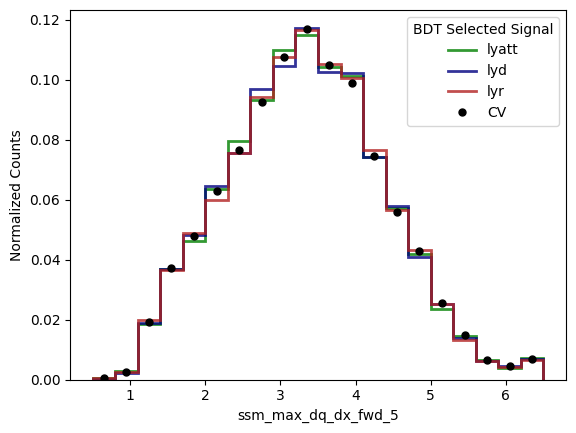

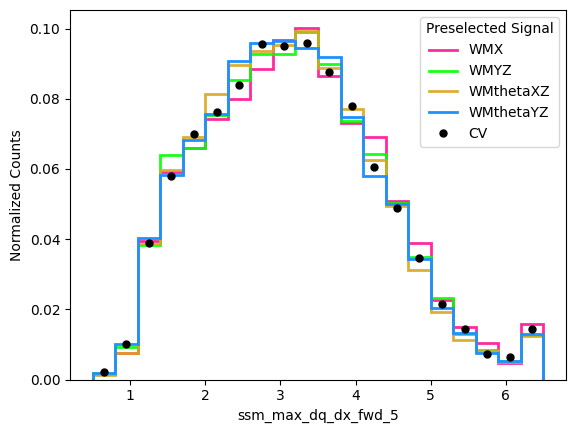

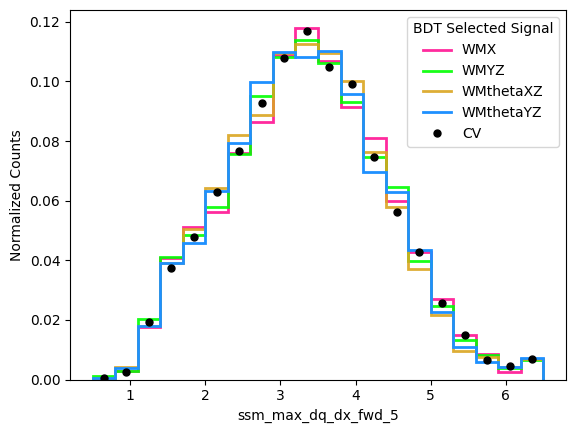

In [33]:
var = 'ssm_max_dq_dx_fwd_5'
xmin = 0.5
xmax = 6.5
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



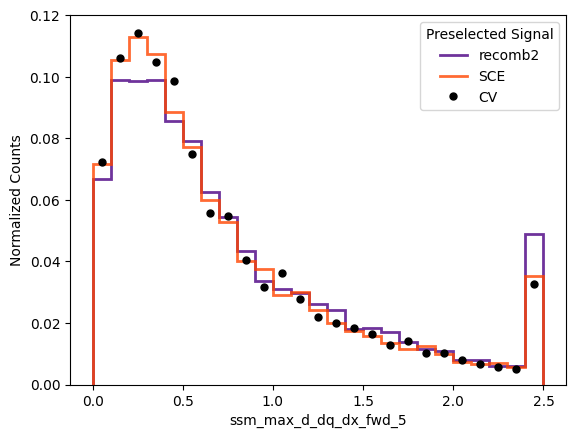

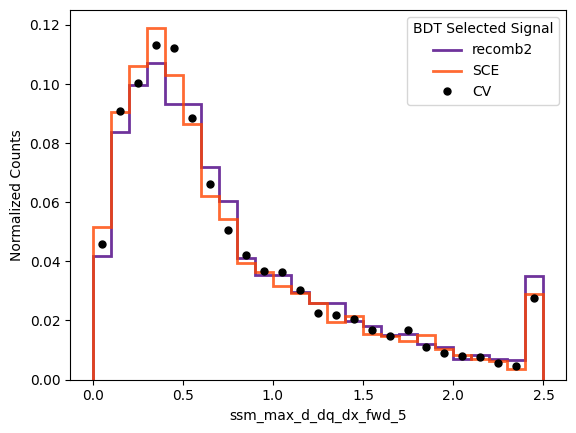

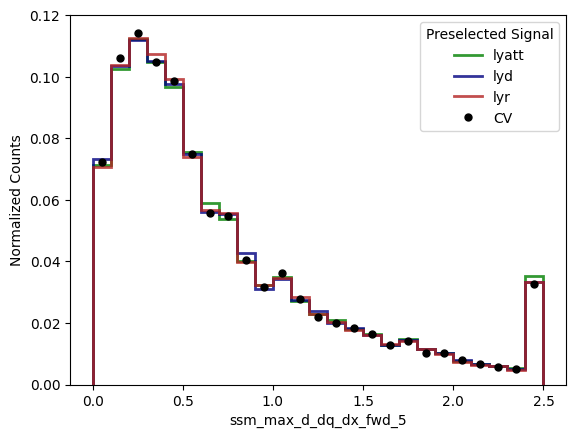

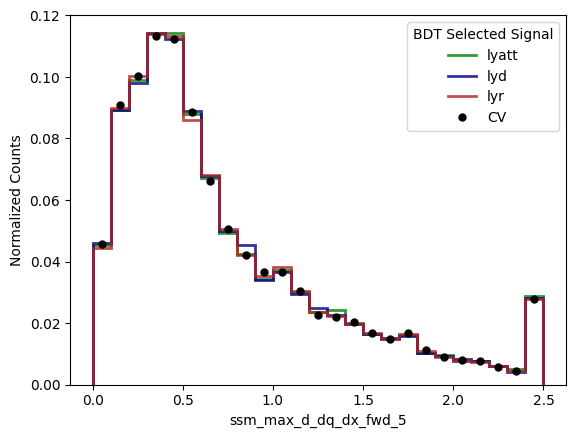

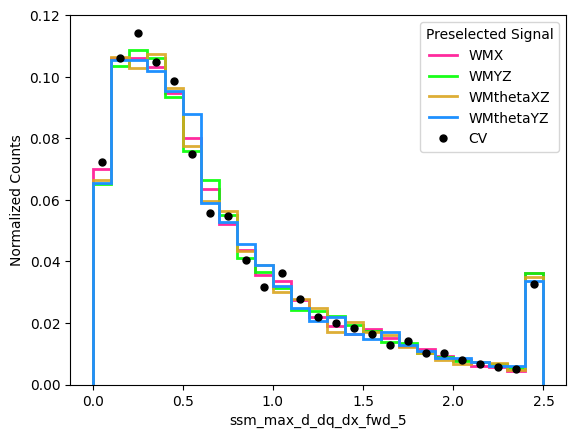

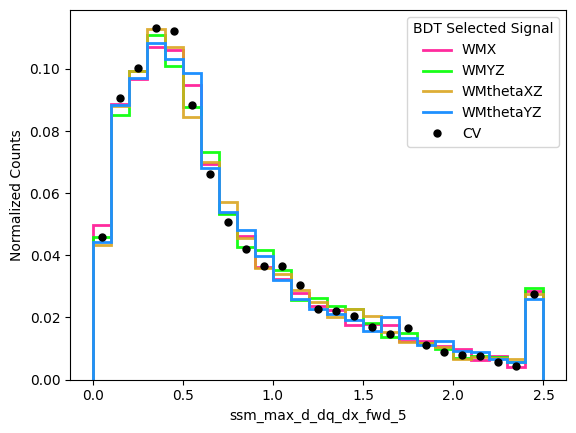

In [34]:
var = 'ssm_max_d_dq_dx_fwd_5'
xmin = 0
xmax = 2.5
nbins = 25
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



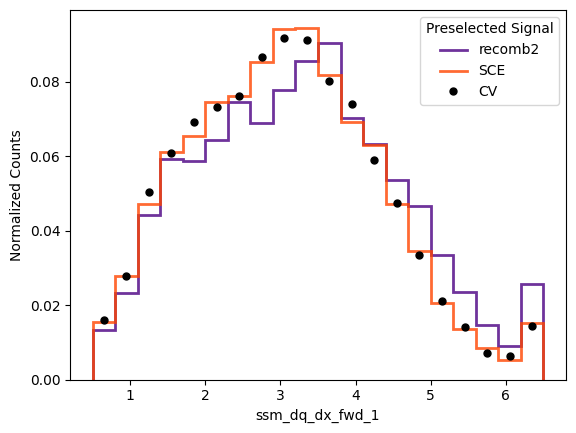

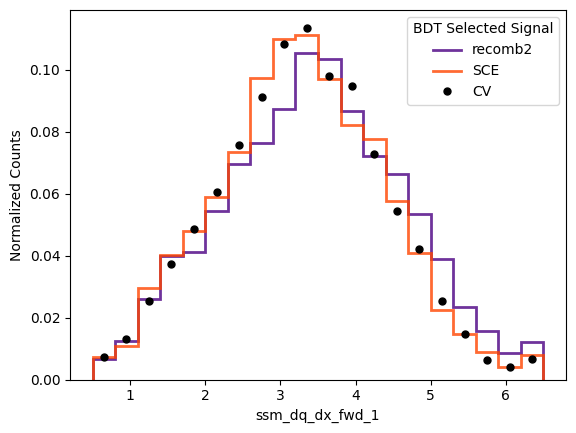

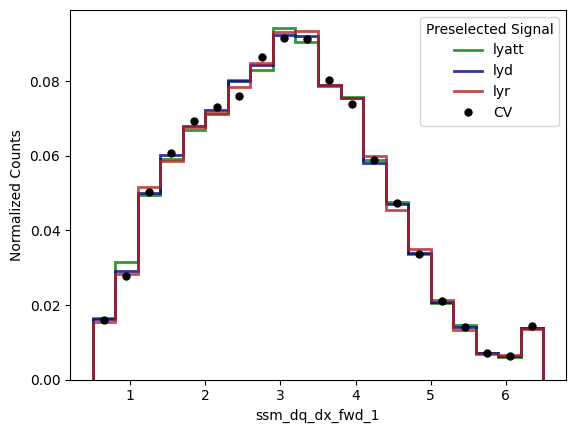

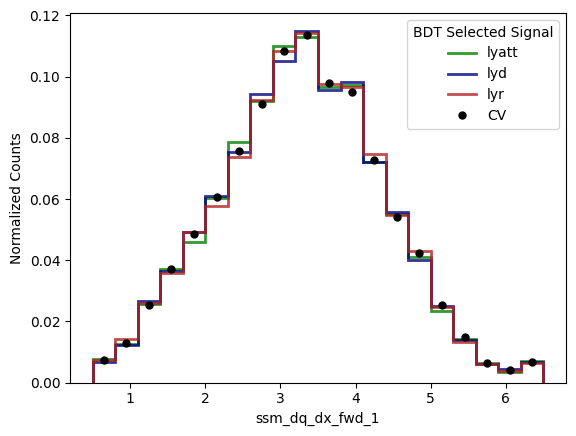

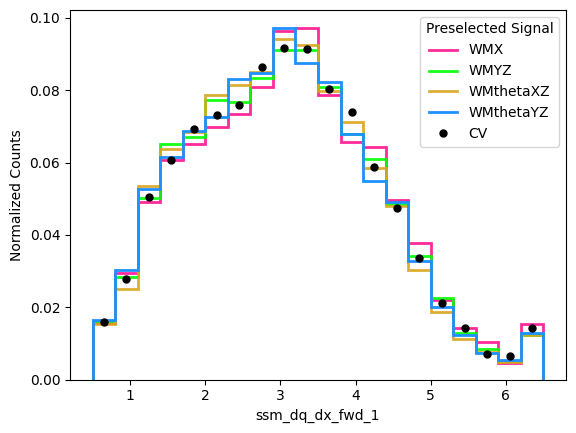

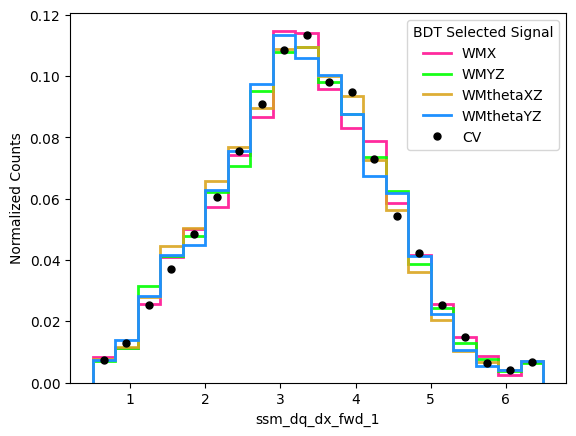

In [35]:
var = 'ssm_dq_dx_fwd_1'
xmin = 0.5
xmax = 6.5
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



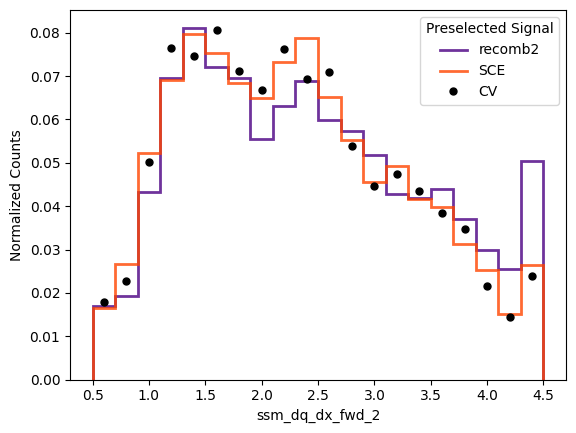

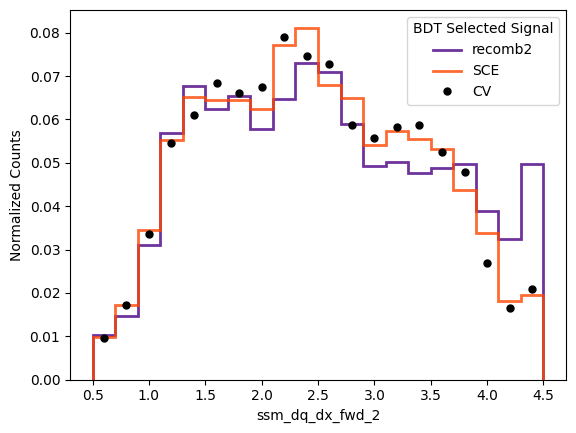

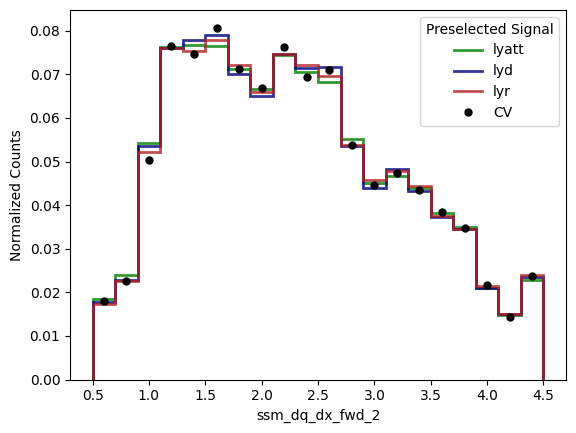

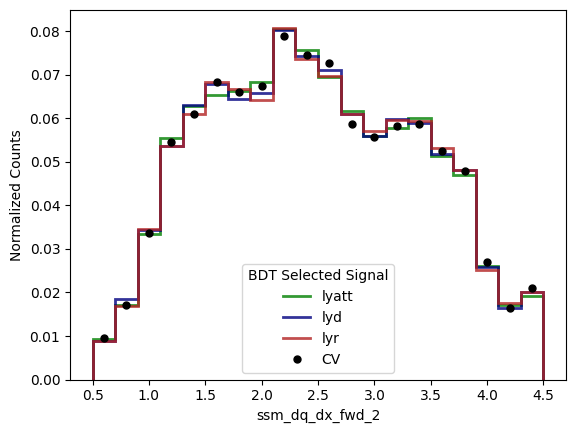

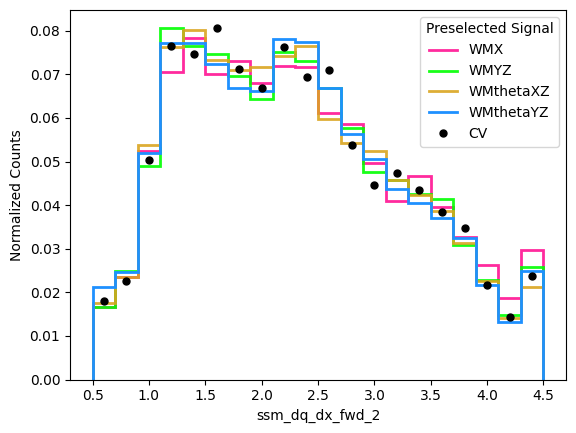

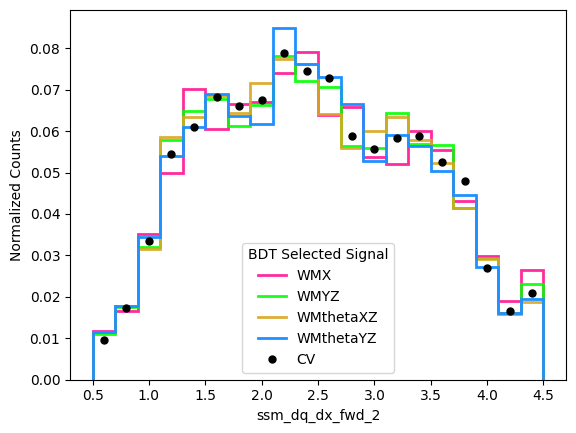

In [36]:
var = 'ssm_dq_dx_fwd_2'
xmin = 0.5
xmax = 4.5
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)



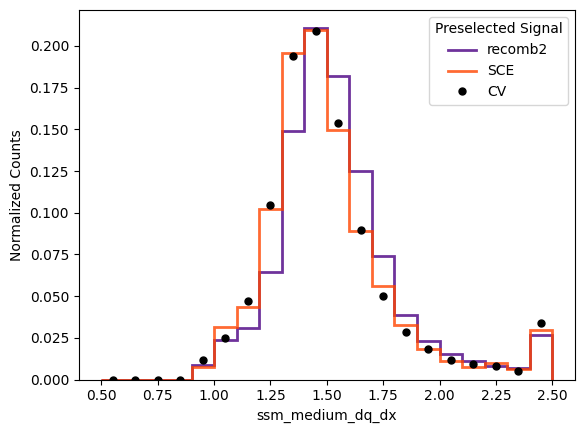

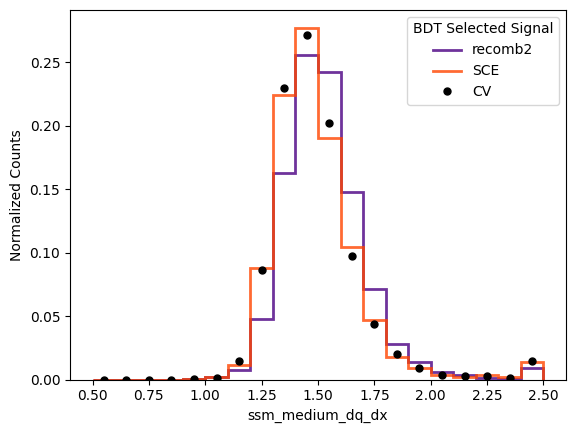

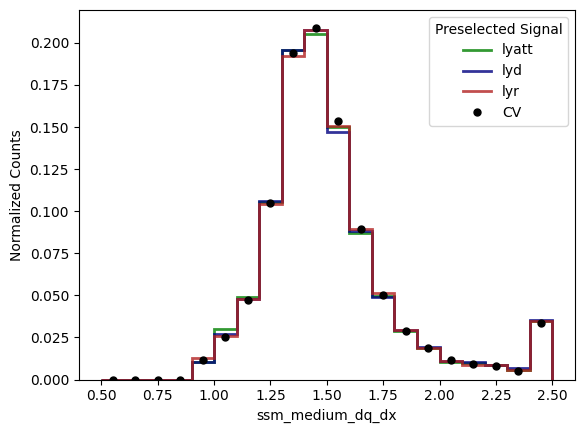

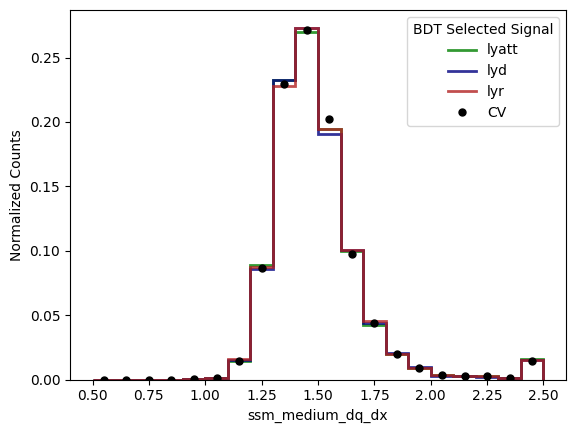

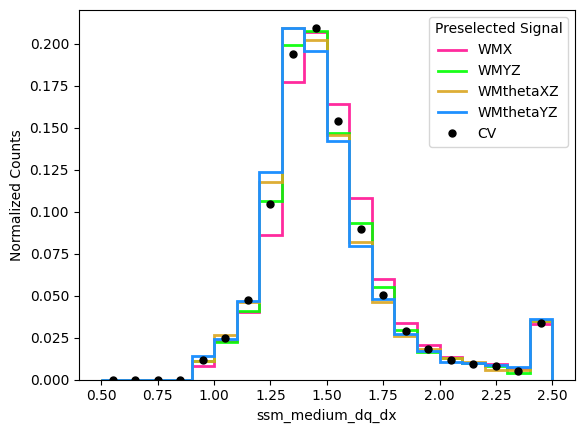

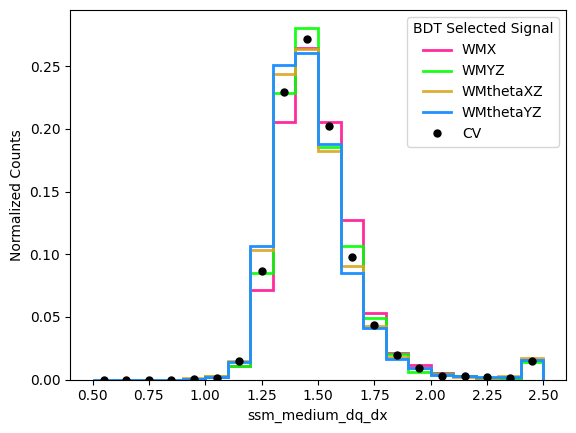

In [37]:
var = 'ssm_medium_dq_dx'
xmin = 0.5
xmax = 2.5
nbins = 20
check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=True,plot_SCE=True,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=True,plot_lyr=True,plot_lyd=True,plot_WMX=False,plot_WMYZ=False,plot_WMthetaXZ=False,plot_WMthetaYZ=False,)

check_var(var,xmin,xmax,nbins,check_presel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,clipped=True,plot_recomb2=False,plot_SCE=False,plot_lyatt=False,plot_lyr=False,plot_lyd=False,plot_WMX=True,plot_WMYZ=True,plot_WMthetaXZ=True,plot_WMthetaYZ=True,)

